# Notebook 16. Cleaned Cluster Composites and Representative Events

This notebook is the cleaned composite-map follow-up to `Notebook 15`.

Why this notebook exists:

- `Notebook 15` showed that the Russian-coastal low-level cleanup changes the subgrouping framework enough that the primary robust solution is now `k = 2`
- the next step is therefore to remake the composite maps and representative-event context from the **cleaned** event groupings rather than the original `k = 3` baseline
- this notebook keeps the upper-level synoptic diagnostics, but recomputes the low-level fields with the Russian-coastal exclusion applied before compositing so the composite maps and counts are internally consistent

What this notebook does:

- loads the cleaned event labels from `Notebook 15`
- uses `cleaned_cluster_ward_2` as the primary composite grouping
- keeps `cleaned_cluster_ward_3` available as exploratory context in the loaded event table
- rebuilds the full-domain composite means, standard deviations, counts, and difference maps
- applies the Russian-coastal exclusion to the terrain-sensitive `850/925 hPa` fields before the composite accumulators are updated
- computes the low-level fields on the original objective-subtype domain and the `300 hPa` diagnostics on the wider `WORKING_DOMAIN`
- embeds the low-level fields onto the working-grid coordinates so the saved composite datasets still share one common grid
- checkpoints climatology files, partial composite accumulators, and final outputs to Drive as they are produced

What this notebook does **not** do:

- it does not rerun the clustering decision logic from `Notebook 15`
- it does not do spatial EOF analysis yet
- it does not do the Cluster-1 moisture-flux quartile analysis or the date-pairing analysis yet


In [6]:

import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/angelicasophyaramirez-blip/JPCZcatalogcolab.git"
BRANCH = "main"
REPO_DIR = "/content/JPCZcatalog"
FORCE_REFRESH_REPO = False
PERSIST_OUTPUTS_TO_DRIVE = True
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/JPCZcatalog_outputs"

if PERSIST_OUTPUTS_TO_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
    print("Persistent output dir:", DRIVE_OUTPUT_DIR)

os.chdir("/content")

if FORCE_REFRESH_REPO and os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)
    print("Removed existing repo clone:", REPO_DIR)

if not os.path.exists(REPO_DIR):
    proc = subprocess.run(
        ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, REPO_DIR],
        text=True,
        capture_output=True,
    )
    print(proc.stdout)
    print(proc.stderr)
    if proc.returncode != 0:
        raise RuntimeError(f"git clone failed:\n{proc.stderr}")

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", f"{REPO_DIR}/requirements-colab.txt"],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", REPO_DIR],
        check=True,
    )
else:
    print("Using existing repo clone:", REPO_DIR)

os.chdir(REPO_DIR)
src_dir = os.path.join(REPO_DIR, "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

print("Working directory:", os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Persistent output dir: /content/drive/MyDrive/JPCZcatalog_outputs
Using existing repo clone: /content/JPCZcatalog
Working directory: /content/JPCZcatalog


In [7]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import xarray as xr

from jpcz_catalog.analysis import add_japan_local_time_columns
from jpcz_catalog.config import (
    COASTAL_JAPAN_BOX,
    HOKKAIDO_BOX,
    HOKKAIDO_FRONT_BOX,
    JPCZ_POLYGON_VERTICES,
    OBJECTIVE_SUBTYPE_DOMAIN,
    PACIFIC_EAST_OF_JAPAN_BOX,
    PACIFIC_FRONT_BOX,
    SEA_OF_JAPAN_BOX,
    WORKING_DOMAIN,
    BoundingBox,
)
from jpcz_catalog.detect import compute_divergence_field, prepare_detection_geometry
from jpcz_catalog.diagnostics import (
    compute_ageostrophic_divergence_field,
    compute_ageostrophic_wind_fields,
    compute_geopotential_height_field,
    compute_geostrophic_wind_fields,
    compute_temperature_gradient_magnitude,
    compute_wind_speed_field,
    load_offset_snapshot,
    load_snapshot,
)
from jpcz_catalog.era5 import open_arco_era5
from jpcz_catalog.satellite import default_modis_layers_for_date
from jpcz_catalog.subtypes import (
    compute_monthly_geopotential_height_climatology,
    feature_definitions_dataframe,
    standardize_feature_table,
)

CLEANED_RUN_EXPORT_DIR = Path("outputs/verification/objective_subtype_low_level_cleaned_sensitivity")
COMPOSITE_EXPORT_DIR = Path("outputs/verification/objective_subtype_cleaned_cluster_examples")
COMPOSITE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = Path("outputs/verification/objective_subtype_cleaned_cluster_example_plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)
CLIMATOLOGY_PATH = Path("outputs/verification/z850_ndjf_monthly_climatology.nc")
Z300_CLIMATOLOGY_PATH = Path("outputs/verification/z300_ndjf_monthly_climatology_working_domain.nc")

CLEANED_CLUSTERED_EVENTS_PATH = CLEANED_RUN_EXPORT_DIR / "clustered_events_cleaned_low_level_k2_k3_k4.csv"
NOTEBOOK15_SOLUTION_SUMMARY_PATH = CLEANED_RUN_EXPORT_DIR / "cleaned_low_level_solution_summary.csv"
NOTEBOOK15_QUALITY_SCAN_LONG_PATH = CLEANED_RUN_EXPORT_DIR / "cleaned_low_level_quality_scan_by_solution.csv"
NOTEBOOK15_FEATURE_COMPARISON_PATH = CLEANED_RUN_EXPORT_DIR / "cleaned_low_level_feature_comparison_by_current_cluster.csv"
NOTEBOOK15_CROSSTAB_PATH = CLEANED_RUN_EXPORT_DIR / "cleaned_low_level_cluster_crosstabs.csv"

QUICKLOOK_DIR = Path("outputs/verification/ndjf_event_quicklooks_merged_12h")
SATELLITE_DIR = Path("outputs/verification/ndjf_event_satellite_panels_merged_12h")
OLR_DIR = Path("outputs/verification/ndjf_event_olr_panels_merged_12h")

LOW_LEVEL_COMPOSITE_DOMAIN = OBJECTIVE_SUBTYPE_DOMAIN
UPPER_LEVEL_COMPOSITE_DOMAIN = WORKING_DOMAIN
LOW_LEVEL_PLOT_DOMAIN = OBJECTIVE_SUBTYPE_DOMAIN
UPPER_LEVEL_PLOT_DOMAIN = WORKING_DOMAIN
PRIMARY_CLUSTER_K = 2
PRIMARY_CLUSTER_COLUMN = f"cleaned_cluster_ward_{PRIMARY_CLUSTER_K}"
EXPLORATORY_CLUSTER_COLUMN = "cleaned_cluster_ward_3"
REPRESENTATIVE_EVENTS_PER_CLUSTER = 5
DISPLAY_REPRESENTATIVE_EVENTS_PER_CLUSTER = 1
SAVE_PLOTS = True
FORCE_REBUILD_CLUSTER_COMPOSITES = False
ERA5_TIME_CHUNK = 48
PROGRESS_EVERY = 10
SYNOPTIC_OFFSETS = (-12, 0, 12)
MIN_FRACTION_EVENTS_TO_PLOT = 0.8

PRIMARY_COMPOSITE_FIELDS = [
    "divergence_925_peak",
    "z850_anomaly_min_tminus12_to_tplus12",
    "temperature_gradient_850_max_tminus12_to_tplus12",
]
ADDITIONAL_SCALAR_COMPOSITE_FIELDS = [
    "vertical_moisture_flux_proxy_850_peak",
    "wind_speed_300_peak",
    "z300_anomaly_peak",
    "divergence_300_peak",
    "ageostrophic_divergence_300_peak",
]
VECTOR_COMPOSITE_FIELDS = [
    "ageostrophic_u_300_peak",
    "ageostrophic_v_300_peak",
]
REPORTABLE_COMPOSITE_FIELDS = PRIMARY_COMPOSITE_FIELDS + ADDITIONAL_SCALAR_COMPOSITE_FIELDS
ALL_COMPOSITE_FIELDS = REPORTABLE_COMPOSITE_FIELDS + VECTOR_COMPOSITE_FIELDS

DEFAULT_MAIN_DISPLAY_LEVELS = {
    "divergence_925_peak": np.arange(-2.0, 2.01, 0.25),
    "z850_anomaly_min_tminus12_to_tplus12": np.arange(-120.0, 120.1, 10.0),
    "temperature_gradient_850_max_tminus12_to_tplus12": np.arange(0.0, 6.1, 0.5),
    "vertical_moisture_flux_proxy_850_peak": np.arange(-0.4, 0.401, 0.05),
}
DEFAULT_DIFFERENCE_DISPLAY_LEVELS = {
    "divergence_925_peak": np.arange(-1.0, 1.01, 0.125),
    "z850_anomaly_min_tminus12_to_tplus12": np.arange(-80.0, 80.1, 10.0),
    "temperature_gradient_850_max_tminus12_to_tplus12": np.arange(-3.0, 3.1, 0.25),
    "vertical_moisture_flux_proxy_850_peak": np.arange(-0.3, 0.301, 0.025),
}

BASELINE_TO_CLEANED_FEATURE_COLUMNS = {
    "coastal_to_jpcz_mean_divergence_ratio": "coastal_to_jpcz_mean_divergence_ratio_russian_coastal_excluded",
    "hokkaido_min_z850_anomaly_tminus12_to_tplus12": "hokkaido_min_z850_anomaly_tminus12_to_tplus12",
    "front_box_max_temp_gradient_850_tminus12_to_tplus12": "front_box_max_temp_gradient_850_tminus12_to_tplus12_russian_coastal_excluded",
    "sea_of_japan_mean_vorticity_peak_925": "sea_of_japan_mean_vorticity_peak_925_russian_coastal_excluded",
}
CLUSTER_FEATURE_COLUMNS = list(BASELINE_TO_CLEANED_FEATURE_COLUMNS.values())

RUSSIAN_COASTAL_EXCLUSION_BOXES = (
    BoundingBox(lon_min=130.5, lon_max=135.5, lat_min=42.0, lat_max=45.0),
    BoundingBox(lon_min=133.5, lon_max=139.5, lat_min=44.0, lat_max=47.25),
)
LOW_LEVEL_FIELDS_WITH_EXCLUSION = {
    "divergence_925_peak",
    "z850_anomaly_min_tminus12_to_tplus12",
    "temperature_gradient_850_max_tminus12_to_tplus12",
    "vertical_moisture_flux_proxy_850_peak",
}
UPPER_LEVEL_FIELDS = {
    "wind_speed_300_peak",
    "z300_anomaly_peak",
    "divergence_300_peak",
    "ageostrophic_divergence_300_peak",
    "ageostrophic_u_300_peak",
    "ageostrophic_v_300_peak",
}

FEATURE_LABELS = {
    "coastal_to_jpcz_mean_divergence_ratio_russian_coastal_excluded": "Coastal/JPCZ signed-divergence ratio (Russian coastal exclusion)",
    "hokkaido_min_z850_anomaly_tminus12_to_tplus12": "Hokkaido minimum z850 anomaly",
    "front_box_max_temp_gradient_850_tminus12_to_tplus12_russian_coastal_excluded": "Front-box maximum |grad T850| (Russian coastal exclusion)",
    "sea_of_japan_mean_vorticity_peak_925_russian_coastal_excluded": "Sea of Japan mean 925 hPa vorticity (Russian coastal exclusion)",
}


def ordinal_word(value: int) -> str:
    lookup = {1: "first", 2: "second", 3: "third", 4: "fourth", 5: "fifth"}
    return lookup.get(value, f"{value}th")


def size_rank_descriptor(rank: int, total: int) -> str:
    if total <= 1:
        return "only subgroup"
    if rank == 1:
        return "largest subgroup"
    if rank == total:
        return "smallest subgroup"
    return f"{ordinal_word(rank)}-largest subgroup"


def build_cluster_labels_from_counts(cluster_counts: pd.Series | dict[int, int]):
    counts_dict = {int(cluster_id): int(n_events) for cluster_id, n_events in dict(cluster_counts).items()}
    ranked = sorted(counts_dict.items(), key=lambda item: (-item[1], item[0]))
    rank_lookup = {cluster_id: rank for rank, (cluster_id, _) in enumerate(ranked, start=1)}
    total = len(ranked)
    long_labels = {}
    short_labels = {}
    rows = []
    for cluster_id, n_events in sorted(counts_dict.items()):
        descriptor = size_rank_descriptor(rank_lookup[cluster_id], total)
        long_labels[cluster_id] = f"Cluster {cluster_id}: n={n_events} ({descriptor})"
        short_labels[cluster_id] = descriptor
        rows.append(
            {
                "cluster_id": cluster_id,
                "n_events": n_events,
                "size_rank": rank_lookup[cluster_id],
                "size_descriptor": descriptor,
                "cluster_label": long_labels[cluster_id],
            }
        )
    return long_labels, short_labels, pd.DataFrame(rows)


def pretty_pair_label(pair_label: str) -> str:
    return pair_label.replace("_minus_", " minus ").replace("cluster_", "Cluster ")


BOXES = {
    "Coastal Japan": COASTAL_JAPAN_BOX,
    "Pacific east of Japan": PACIFIC_EAST_OF_JAPAN_BOX,
    "Hokkaido": HOKKAIDO_BOX,
    "Sea of Japan": SEA_OF_JAPAN_BOX,
    "Hokkaido front": HOKKAIDO_FRONT_BOX,
    "Pacific front": PACIFIC_FRONT_BOX,
}

FEATURE_DICTIONARY = feature_definitions_dataframe()
FEATURE_UNITS = FEATURE_DICTIONARY.set_index("column_name")["units"].to_dict()
FEATURE_UNITS.update(
    {
        "coastal_to_jpcz_mean_divergence_ratio_russian_coastal_excluded": "unitless",
        "front_box_max_temp_gradient_850_tminus12_to_tplus12_russian_coastal_excluded": "K (100 km)^-1",
        "sea_of_japan_mean_vorticity_peak_925_russian_coastal_excluded": "1e-5 s^-1",
    }
)

COMPOSITE_MEAN_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_working_domain_cluster_composite_means.nc"
COMPOSITE_STD_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_working_domain_cluster_composite_std.nc"
COMPOSITE_COUNT_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_working_domain_cluster_composite_counts.nc"
COMPOSITE_EVENT_BOX_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_event_level_box_means.csv"
COMPOSITE_BOX_SUMMARY_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_cluster_box_mean_summary.csv"
COMPOSITE_MAP_BOX_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_cluster_composite_map_box_means.csv"
COMPOSITE_DIFF_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_cluster_difference_maps.nc"
COMPOSITE_FIELD_MEAN_SUMMARY_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_cluster_composite_field_mean_summary.csv"
PCA_VARIANCE_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_pca_variance_summary.csv"
PCA_LOADINGS_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_pca_loadings_summary.csv"
PCA_DRIVER_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_pca_driver_summary.csv"
PARTIAL_STATUS_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_working_domain_cluster_composite_partial_status.csv"
REPRESENTATIVES_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_representative_events.csv"
CLUSTER_STORY_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_cluster_summary_metrics.csv"
CLUSTER_MEAN_GROUPED_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_cluster_composite_field_mean_summary_grouped_by_field.csv"
SAMPLE_COUNT_SUMMARY_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_cluster_sample_count_summary.csv"
PLOT_SUMMARY_PATH = COMPOSITE_EXPORT_DIR / "cleaned_k2_plot_inventory.csv"


def maybe_copy_to_drive(path: Path, *, verbose: bool = True):
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return None
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if path.is_file():
        shutil.copy2(path, drive_path)
        if verbose:
            print("Copied to Drive:", drive_path)
        return drive_path
    return None



def restore_from_drive_cache(path: Path) -> bool:
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return False
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if not drive_path.exists():
        return False
    path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(drive_path, path)
    print("Restored from Drive:", drive_path, "->", path)
    return True



def axis_label(column_name: str) -> str:
    label = FEATURE_LABELS.get(column_name, column_name)
    units = FEATURE_UNITS.get(column_name)
    if units is None or units == "unitless":
        return label
    return f"{label}\n[{units}]"



def quicklook_name_for_row(row_index: int, row: pd.Series) -> str:
    return f"{pd.Timestamp(row['event_peak']).strftime('%Y%m%dT%H%M')}_idx{row_index:03d}.png"



def satellite_name_for_row(row_index: int, row: pd.Series) -> str | None:
    satellite_layers = default_modis_layers_for_date(pd.Timestamp(row['event_peak']).normalize())
    if not satellite_layers:
        return None
    satellite_layer = satellite_layers[0]
    layer_slug = (
        satellite_layer.replace("MODIS_", "")
        .replace("_CorrectedReflectance_TrueColor", "")
        .lower()
    )
    return f"{pd.Timestamp(row['event_peak']).strftime('%Y%m%dT%H%M')}_idx{row_index:03d}_{layer_slug}.jpg"



def ensure_local_copy(local_path: Path, drive_subdir_name: str) -> bool:
    if local_path.exists():
        return True
    drive_path = Path(DRIVE_OUTPUT_DIR) / drive_subdir_name / local_path.name
    if not drive_path.exists():
        return False
    local_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(drive_path, local_path)
    return True



def build_russian_coastal_keep_mask(target_field: xr.DataArray) -> xr.DataArray:
    lat_vals = np.asarray(target_field.latitude.values, dtype=float)
    lon_vals = np.asarray(target_field.longitude.values, dtype=float)
    lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)
    keep_mask = np.ones((len(lat_vals), len(lon_vals)), dtype=bool)
    for box in RUSSIAN_COASTAL_EXCLUSION_BOXES:
        in_box = (
            (lon2d >= box.lon_min)
            & (lon2d <= box.lon_max)
            & (lat2d >= box.lat_min)
            & (lat2d <= box.lat_max)
        )
        keep_mask &= ~in_box
    return xr.DataArray(
        keep_mask,
        coords={"latitude": target_field.latitude, "longitude": target_field.longitude},
        dims=("latitude", "longitude"),
        name="russian_coastal_keep_mask",
    )



def embed_on_working_grid(field: xr.DataArray, working_longitude: xr.DataArray, working_latitude: xr.DataArray) -> xr.DataArray:
    embedded = field.reindex(latitude=working_latitude.values, longitude=working_longitude.values)
    embedded.attrs.update(field.attrs)
    return embedded



def plot_domain_for_field(field_name: str):
    return UPPER_LEVEL_PLOT_DOMAIN if field_name in UPPER_LEVEL_FIELDS else LOW_LEVEL_PLOT_DOMAIN



def lat_weighted_box_mean(field: xr.DataArray, box) -> float:
    subset = field.sel(
        longitude=slice(box.lon_min, box.lon_max),
        latitude=slice(box.lat_max, box.lat_min),
    )
    if subset.size == 0:
        return float("nan")
    lat_weights = xr.DataArray(
        np.cos(np.deg2rad(subset.latitude.values)),
        coords={"latitude": subset.latitude.values},
        dims=("latitude",),
    ).broadcast_like(subset)
    valid = xr.apply_ufunc(np.isfinite, subset)
    numerator = (subset.where(valid, 0.0) * lat_weights.where(valid, 0.0)).sum()
    denominator = lat_weights.where(valid, 0.0).sum()
    denominator_value = float(denominator.values)
    if denominator_value <= 0.0:
        return float("nan")
    return float((numerator / denominator).values)



def initialize_accumulator_dataset(event_ds: xr.Dataset) -> xr.Dataset:
    data_vars = {}
    for field_name in event_ds.data_vars:
        field = event_ds[field_name]
        valid = xr.apply_ufunc(np.isfinite, field)
        filled = field.where(valid, 0.0)
        data_vars[f"sum__{field_name}"] = filled.astype(float)
        data_vars[f"sumsq__{field_name}"] = (filled ** 2).astype(float)
        data_vars[f"count__{field_name}"] = valid.astype(np.int32)
    return xr.Dataset(data_vars)



def update_accumulator_dataset(accumulator_ds: xr.Dataset, event_ds: xr.Dataset) -> xr.Dataset:
    updates = {}
    for field_name in event_ds.data_vars:
        field = event_ds[field_name]
        valid = xr.apply_ufunc(np.isfinite, field)
        filled = field.where(valid, 0.0)
        updates[f"sum__{field_name}"] = accumulator_ds[f"sum__{field_name}"] + filled.astype(float)
        updates[f"sumsq__{field_name}"] = accumulator_ds[f"sumsq__{field_name}"] + (filled ** 2).astype(float)
        updates[f"count__{field_name}"] = accumulator_ds[f"count__{field_name}"] + valid.astype(np.int32)
    return xr.Dataset(updates)



def finalize_accumulator_dataset(accumulator_ds: xr.Dataset):
    mean_vars = {}
    std_vars = {}
    count_vars = {}
    for variable_name in accumulator_ds.data_vars:
        if not variable_name.startswith("sum__"):
            continue
        field_name = variable_name.replace("sum__", "")
        field_sum = accumulator_ds[f"sum__{field_name}"]
        field_sumsq = accumulator_ds[f"sumsq__{field_name}"]
        field_count = accumulator_ds[f"count__{field_name}"]
        safe_count = field_count.where(field_count > 0)
        field_mean = (field_sum / safe_count).where(field_count > 0)
        field_variance = ((field_sumsq / safe_count) - (field_mean ** 2)).where(field_count > 0)
        field_std = np.sqrt(field_variance.clip(min=0.0)).where(field_count > 0)
        mean_vars[field_name] = field_mean
        std_vars[field_name] = field_std
        count_vars[field_name] = field_count
    return xr.Dataset(mean_vars), xr.Dataset(std_vars), xr.Dataset(count_vars)



def write_partial_accumulator_checkpoint(
    accumulator_ds: xr.Dataset,
    *,
    cluster_id: int,
    processed_events: int,
    total_events: int,
    partial_path: Path,
):
    checkpoint_ds = accumulator_ds.copy()
    checkpoint_ds.attrs["cluster_id"] = int(cluster_id)
    checkpoint_ds.attrs["processed_events"] = int(processed_events)
    checkpoint_ds.attrs["total_events"] = int(total_events)
    checkpoint_ds.to_netcdf(partial_path)
    maybe_copy_to_drive(partial_path)



def write_partial_status(status_lookup: dict[int, dict[str, object]]):
    partial_status_df = pd.DataFrame(status_lookup.values()).sort_values("cluster_id")
    partial_status_df.to_csv(PARTIAL_STATUS_PATH, index=False)
    maybe_copy_to_drive(PARTIAL_STATUS_PATH)


In [8]:
paths_to_restore = [
    CLEANED_CLUSTERED_EVENTS_PATH,
    NOTEBOOK15_SOLUTION_SUMMARY_PATH,
    NOTEBOOK15_QUALITY_SCAN_LONG_PATH,
    NOTEBOOK15_FEATURE_COMPARISON_PATH,
    NOTEBOOK15_CROSSTAB_PATH,
]
for path in paths_to_restore:
    if not path.exists():
        restore_from_drive_cache(path)

clustered_k3_df = pd.read_csv(CLEANED_CLUSTERED_EVENTS_PATH)
clustered_k3_df = add_japan_local_time_columns(clustered_k3_df)
if PRIMARY_CLUSTER_COLUMN not in clustered_k3_df.columns:
    cluster_cols = [c for c in clustered_k3_df.columns if c.startswith("cluster_")]
    raise RuntimeError(f"Expected {PRIMARY_CLUSTER_COLUMN} in {CLEANED_CLUSTERED_EVENTS_PATH.name}, found {cluster_cols}")

missing_columns = [column for column in CLUSTER_FEATURE_COLUMNS if column not in clustered_k3_df.columns]
if missing_columns:
    raise RuntimeError(f"Missing cleaned clustering-feature columns: {missing_columns}")

cluster_counts_df = (
    clustered_k3_df[PRIMARY_CLUSTER_COLUMN]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .rename("n_events")
    .to_frame()
)
cluster_medians_df = clustered_k3_df.groupby(PRIMARY_CLUSTER_COLUMN)[CLUSTER_FEATURE_COLUMNS].median(numeric_only=True).round(3)
cluster_event_counts = cluster_counts_df["n_events"].to_dict()
CLUSTER_LABELS, CLUSTER_MAP_LABELS, cluster_label_df = build_cluster_labels_from_counts(cluster_event_counts)

notebook15_solution_summary_df = pd.read_csv(NOTEBOOK15_SOLUTION_SUMMARY_PATH) if NOTEBOOK15_SOLUTION_SUMMARY_PATH.exists() else pd.DataFrame()
notebook15_quality_scan_df = pd.read_csv(NOTEBOOK15_QUALITY_SCAN_LONG_PATH) if NOTEBOOK15_QUALITY_SCAN_LONG_PATH.exists() else pd.DataFrame()
notebook15_feature_comparison_df = pd.read_csv(NOTEBOOK15_FEATURE_COMPARISON_PATH) if NOTEBOOK15_FEATURE_COMPARISON_PATH.exists() else pd.DataFrame()
notebook15_crosstab_df = pd.read_csv(NOTEBOOK15_CROSSTAB_PATH) if NOTEBOOK15_CROSSTAB_PATH.exists() else pd.DataFrame()

cleaned_k2_vs_k3_counts_df = pd.crosstab(
    clustered_k3_df[PRIMARY_CLUSTER_COLUMN].astype(int),
    clustered_k3_df[EXPLORATORY_CLUSTER_COLUMN].astype(int),
)
cleaned_k2_vs_k3_fraction_df = cleaned_k2_vs_k3_counts_df.div(cleaned_k2_vs_k3_counts_df.sum(axis=1), axis=0).round(3)

standardized_df, feature_means, feature_stds = standardize_feature_table(
    clustered_k3_df.copy(),
    columns=CLUSTER_FEATURE_COLUMNS,
)
cluster_labels = clustered_k3_df[PRIMARY_CLUSTER_COLUMN]
valid_mask = standardized_df.notna().all(axis=1) & cluster_labels.notna()
standardized_valid = standardized_df.loc[valid_mask].copy()
labels_valid = cluster_labels.loc[valid_mask].astype(int)
centroids = standardized_valid.groupby(labels_valid).mean()

valid_matrix = standardized_valid.to_numpy(dtype=float)
_, singular_values, vt = np.linalg.svd(valid_matrix, full_matrices=False)
pca_components = vt[:3]
total_variance = float((singular_values ** 2).sum())
pca_explained_variance_ratio = (singular_values[:3] ** 2) / total_variance
pca_variance_df = pd.DataFrame(
    {
        "principal_component": ["PC1", "PC2", "PC3"],
        "explained_variance_ratio": pca_explained_variance_ratio,
        "explained_variance_percent": pca_explained_variance_ratio * 100.0,
        "cumulative_explained_variance_ratio": np.cumsum(pca_explained_variance_ratio),
        "cumulative_explained_variance_percent": np.cumsum(pca_explained_variance_ratio) * 100.0,
    }
)
pca_loadings_df = pd.DataFrame(
    pca_components.T,
    index=CLUSTER_FEATURE_COLUMNS,
    columns=["PC1", "PC2", "PC3"],
).reset_index().rename(columns={"index": "feature_column"})
pca_loadings_df.insert(1, "plot_label", pca_loadings_df["feature_column"].map(axis_label))
pca_loadings_df.insert(2, "units", pca_loadings_df["feature_column"].map(lambda value: FEATURE_UNITS.get(value, "")))

pca_driver_rows = []
for pc_name in ["PC1", "PC2", "PC3"]:
    pc_subset = pca_loadings_df[["feature_column", "plot_label", pc_name]].copy()
    pc_subset["abs_loading"] = pc_subset[pc_name].abs()
    pc_subset = pc_subset.sort_values("abs_loading", ascending=False).reset_index(drop=True)
    pca_driver_rows.append(
        {
            "principal_component": pc_name,
            "explained_variance_percent": float(
                pca_variance_df.loc[pca_variance_df["principal_component"] == pc_name, "explained_variance_percent"].iloc[0]
            ),
            "top_driver_feature": pc_subset.loc[0, "feature_column"],
            "top_driver_label": pc_subset.loc[0, "plot_label"],
            "top_driver_loading": float(pc_subset.loc[0, pc_name]),
            "second_driver_feature": pc_subset.loc[1, "feature_column"],
            "second_driver_label": pc_subset.loc[1, "plot_label"],
            "second_driver_loading": float(pc_subset.loc[1, pc_name]),
        }
    )
pca_driver_df = pd.DataFrame(pca_driver_rows)
pca_variance_df.to_csv(PCA_VARIANCE_PATH, index=False)
pca_loadings_df.to_csv(PCA_LOADINGS_PATH, index=False)
pca_driver_df.to_csv(PCA_DRIVER_PATH, index=False)
for path_to_copy in [PCA_VARIANCE_PATH, PCA_LOADINGS_PATH, PCA_DRIVER_PATH]:
    maybe_copy_to_drive(path_to_copy, verbose=False)

representative_records = []
for cluster_id in sorted(centroids.index):
    member_index = labels_valid.index[labels_valid == cluster_id]
    member_points = standardized_valid.loc[member_index]
    centroid = centroids.loc[cluster_id]
    distances = np.sqrt(((member_points - centroid) ** 2).sum(axis=1))
    top_members = distances.sort_values().head(REPRESENTATIVE_EVENTS_PER_CLUSTER)

    for rank_within_cluster, (row_index, centroid_distance) in enumerate(top_members.items(), start=1):
        row = clustered_k3_df.loc[row_index].copy()
        quicklook_name = quicklook_name_for_row(row_index, row)
        satellite_name = satellite_name_for_row(row_index, row)
        olr_name = quicklook_name
        quicklook_exists = ((QUICKLOOK_DIR / quicklook_name).exists() or (Path(DRIVE_OUTPUT_DIR) / QUICKLOOK_DIR.name / quicklook_name).exists())
        olr_exists = ((OLR_DIR / olr_name).exists() or (Path(DRIVE_OUTPUT_DIR) / OLR_DIR.name / olr_name).exists())
        satellite_exists = False if satellite_name is None else ((SATELLITE_DIR / satellite_name).exists() or (Path(DRIVE_OUTPUT_DIR) / SATELLITE_DIR.name / satellite_name).exists())
        representative_records.append(
            {
                "cluster_id": int(cluster_id),
                "cluster_label": CLUSTER_LABELS.get(int(cluster_id), f"Cluster {int(cluster_id)}"),
                "representative_rank": int(rank_within_cluster),
                "catalog_index": int(row_index),
                "centroid_distance": float(centroid_distance),
                "event_peak_utc": pd.Timestamp(row["event_peak"]),
                "event_peak_jst": pd.Timestamp(row["event_peak_jst"]) if pd.notna(row.get("event_peak_jst")) else pd.NaT,
                "duration_hours": float(row["duration_hours"]),
                "event_peak_D_1e5_s-1": float(row["event_peak_D_1e5_s-1"]),
                "coastal_to_jpcz_mean_divergence_ratio_russian_coastal_excluded": float(row["coastal_to_jpcz_mean_divergence_ratio_russian_coastal_excluded"]),
                "sea_of_japan_mean_vorticity_peak_925_russian_coastal_excluded": float(row["sea_of_japan_mean_vorticity_peak_925_russian_coastal_excluded"]),
                "hokkaido_min_z850_anomaly_tminus12_to_tplus12": float(row["hokkaido_min_z850_anomaly_tminus12_to_tplus12"]),
                "front_box_max_temp_gradient_850_tminus12_to_tplus12_russian_coastal_excluded": float(row["front_box_max_temp_gradient_850_tminus12_to_tplus12_russian_coastal_excluded"]),
                "quicklook_name": quicklook_name,
                "olr_name": olr_name,
                "satellite_name": satellite_name,
                "quicklook_exists": bool(quicklook_exists),
                "olr_exists": bool(olr_exists),
                "satellite_exists": bool(satellite_exists),
            }
        )

representative_events_df = pd.DataFrame(representative_records).sort_values(["cluster_id", "representative_rank"]).reset_index(drop=True)
representative_events_df.to_csv(REPRESENTATIVES_PATH, index=False)
maybe_copy_to_drive(REPRESENTATIVES_PATH)

print("Loaded cleaned low-level clustering outputs from Notebook 15")
display(cluster_counts_df)
print("\nNotebook 15 cleaned-feature solution summary")
display(notebook15_solution_summary_df)
print("\nNotebook 15 cleaned-feature quality scan")
display(notebook15_quality_scan_df)
print("\nNotebook 15 per-current-cluster feature comparison")
display(notebook15_feature_comparison_df)
print("\nCleaned k=2 versus cleaned k=3 nesting counts")
display(cleaned_k2_vs_k3_counts_df)
print("\nCleaned k=2 versus cleaned k=3 nesting row fractions")
display(cleaned_k2_vs_k3_fraction_df)
print("\nPCA diagnostics for the cleaned clustering variables")
display(pca_variance_df)
display(pca_loadings_df)
print("\nTop loading drivers for each principal component")
display(pca_driver_df)
print("\nRepresentative events nearest the cleaned k=2 cluster centroids")
display(representative_events_df)


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_representative_events.csv
Loaded cleaned low-level clustering outputs from Notebook 15


,n_events
cleaned_cluster_ward_2,
1,180
2,21



Notebook 15 cleaned-feature solution summary


,solution,n_clusters,feature_columns,silhouette,cluster_counts,recommended_cleaned_solution
0,baseline_current_features,2,"coastal_to_jpcz_mean_divergence_ratio, hokkaid...",0.27398,"1:134, 2:67",False
1,russian_coastal_cleaned_low_level,2,coastal_to_jpcz_mean_divergence_ratio_russian_...,0.45611,"1:180, 2:21",True
2,baseline_current_features,3,"coastal_to_jpcz_mean_divergence_ratio, hokkaid...",0.28136,"1:134, 2:20, 3:47",False
3,russian_coastal_cleaned_low_level,3,coastal_to_jpcz_mean_divergence_ratio_russian_...,0.19569,"1:104, 2:21, 3:76",False
4,baseline_current_features,4,"coastal_to_jpcz_mean_divergence_ratio, hokkaid...",0.24225,"1:42, 2:92, 3:20, 4:47",False
5,russian_coastal_cleaned_low_level,4,coastal_to_jpcz_mean_divergence_ratio_russian_...,0.18320,"1:46, 2:58, 3:21, 4:76",False



Notebook 15 cleaned-feature quality scan


...

,feature_column,plot_label,units,PC1,PC2,PC3
0,coastal_to_jpcz_mean_divergence_ratio_russian_...,Coastal/JPCZ signed-divergence ratio (Russian ...,unitless,0.470101,0.568640,0.653151
1,hokkaido_min_z850_anomaly_tminus12_to_tplus12,Hokkaido minimum z850 anomaly\n[gpm],gpm,-0.455606,0.669408,-0.373060
2,front_box_max_temp_gradient_850_tminus12_to_tp...,Front-box maximum |grad T850| (Russian coastal...,K (100 km)^-1,0.547464,-0.291768,-0.326142
3,sea_of_japan_mean_vorticity_peak_925_russian_c...,Sea of Japan mean 925 hPa vorticity (Russian c...,1e-5 s^-1,0.521259,0.378699,-0.572583



Top loading drivers for each principal component


,principal_component,explained_variance_percent,top_driver_feature,top_driver_label,top_driver_loading,second_driver_feature,second_driver_label,second_driver_loading
0,PC1,47.436394,front_box_max_temp_gradient_850_tminus12_to_tp...,Front-box maximum |grad T850| (Russian coastal...,0.547464,sea_of_japan_mean_vorticity_peak_925_russian_c...,Sea of Japan mean 925 hPa vorticity (Russian c...,0.521259
1,PC2,22.363814,hokkaido_min_z850_anomaly_tminus12_to_tplus12,Hokkaido minimum z850 anomaly\n[gpm],0.669408,coastal_to_jpcz_mean_divergence_ratio_russian_...,Coastal/JPCZ signed-divergence ratio (Russian ...,0.568640
2,PC3,16.118875,coastal_to_jpcz_mean_divergence_ratio_russian_...,Coastal/JPCZ signed-divergence ratio (Russian ...,0.653151,sea_of_japan_mean_vorticity_peak_925_russian_c...,Sea of Japan mean 925 hPa vorticity (Russian c...,-0.572583



Representative events nearest the cleaned k=2 cluster centroids


,cluster_id,cluster_label,representative_rank,catalog_index,centroid_distance,event_peak_utc,event_peak_jst,duration_hours,event_peak_D_1e5_s-1,coastal_to_jpcz_mean_divergence_ratio_russian_coastal_excluded,sea_of_japan_mean_vorticity_peak_925_russian_coastal_excluded,hokkaido_min_z850_anomaly_tminus12_to_tplus12,front_box_max_temp_gradient_850_tminus12_to_tplus12_russian_coastal_excluded,quicklook_name,olr_name,satellite_name,quicklook_exists,olr_exists,satellite_exists
0,1,Cluster 1: n=180 (largest subgroup),1,184,0.277402,2017-11-18 00:00:00,2017-11-18 09:00:00,11.0,-2.635950,0.395350,1.243251,-120.511108,8.829422,20171118T0000_idx184.png,20171118T0000_idx184.png,20171118T0000_idx184_terra.jpg,True,True,True
1,1,Cluster 1: n=180 (largest subgroup),2,162,0.376866,2015-02-12 04:00:00,2015-02-12 13:00:00,9.0,-2.502391,0.551387,1.273609,-131.640015,7.653009,20150212T0400_idx162.png,20150212T0400_idx162.png,20150212T0400_idx162_terra.jpg,True,True,True
2,1,Cluster 1: n=180 (largest subgroup),3,159,0.381449,2015-01-11 03:00:00,2015-01-11 12:00:00,6.0,-2.681582,0.513007,1.174661,-129.777954,7.291023,20150111T0300_idx159.png,20150111T0300_idx159.png,20150111T0300_idx159_terra.jpg,True,True,True
3,1,Cluster 1: n=180 (largest subgroup),4,186,0.444768,2017-11-22 21:00:00,2017-11-23 06:00:00,3.0,-1.935781,0.385148,0.844458,-132.635010,7.307941,20171122T2100_idx186.png,20171122T2100_idx186.png,20171122T2100_idx186_terra.jpg,True,True,True
4,1,Cluster 1: n=180 (largest subgroup),5,68,0.453172,2005-12-12 02:00:00,2005-12-12 11:00:00,10.0,-3.130867,0.589137,0.611411,-123.614258,9.158193,20051212T0200_idx068.png,20051212T0200_idx068.png,20051212T0200_idx068_terra.jpg,True,True,True
5,2,Cluster 2: n=21 (smallest subgroup),1,56,1.435321,2004-12-31 06:00:00,2004-12-31 15:00:00,6.0,-2.773208,0.972751,1.085937,-164.541138,19.841910,20041231T0600_idx056.png,20041231T0600_idx056.png,20041231T0600_idx056_terra.jpg,True,True,True
6,2,Cluster 2: n=21 (smallest subgroup),2,179,1.494433,2017-02-17 02:00:00,2017-02-17 11:00:00,10.0,-3.013857,1.309468,1.173435,-129.251709,20.521609,20170217T0200_idx179.png,20170217T0200_idx179.png,20170217T0200_idx179_terra.jpg,True,True,True
7,2,Cluster 2: n=21 (smallest subgroup),3,92,1.641871,2008-11-27 22:00:00,2008-11-28 07:00:00,8.0,-2.222747,0.647612,1.295329,-142.652466,15.311580,20081127T2200_idx092.png,20081127T2200_idx092.png,20081127T2200_idx092_terra.jpg,True,True,True
8,2,Cluster 2: n=21 (smallest subgroup),4,9,1.649819,2000-11-20 05:00:00,2000-11-20 14:00:00,7.0,-2.018676,2.242250,3.047277,-163.738037,15.829692,20001120T0500_idx009.png,20001120T0500_idx009.png,20001120T0500_idx009_terra.jpg,True,True,True
9,2,Cluster 2: n=21 (smallest subgroup),5,69,1.917560,2005-12-17 07:00:00,2005-12-17 16:00:00,10.0,-3.039767,0.391385,2.018384,-146.127930,14.716897,20051217T0700_idx069.png,20051217T0700_idx069.png,20051217T0700_idx069_terra.jpg,True,True,True


Cluster 1: n=180 (largest subgroup)
catalog idx 184 | UTC 2017-11-18 00:00 | JST 2017-11-18 09:00 | centroid distance 0.277


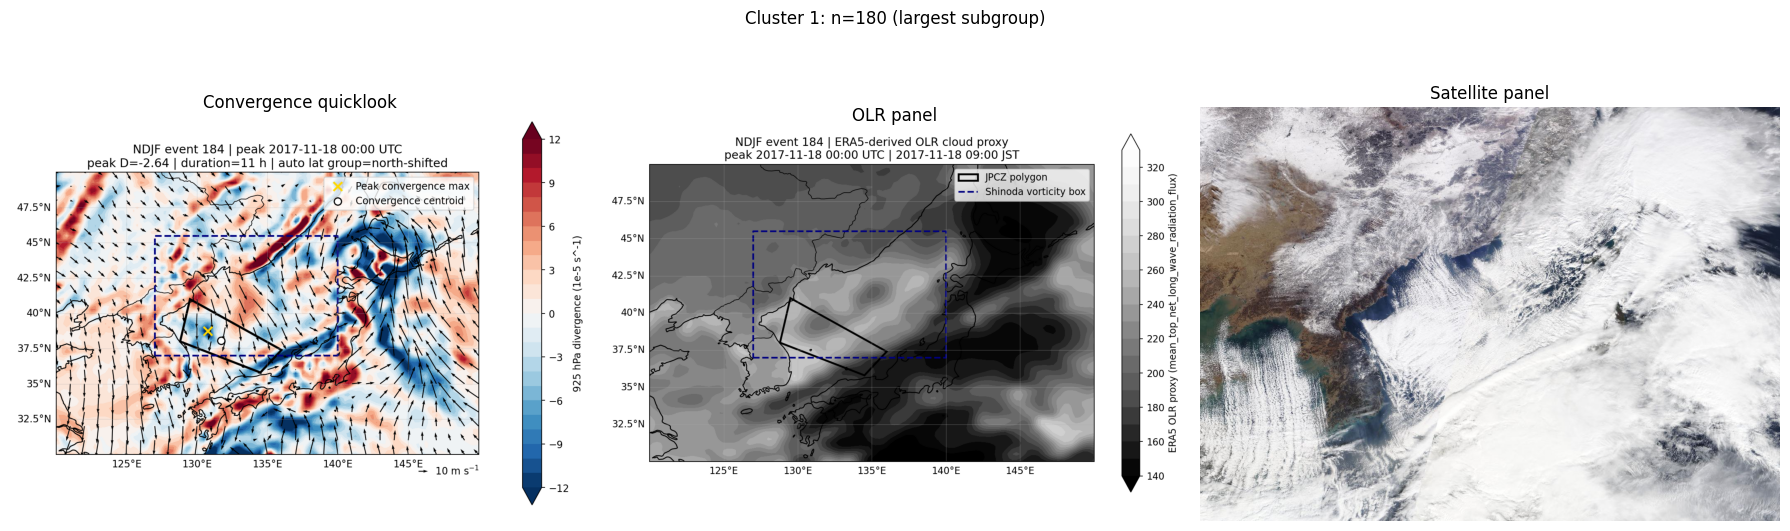

Cluster 2: n=21 (smallest subgroup)
catalog idx 56 | UTC 2004-12-31 06:00 | JST 2004-12-31 15:00 | centroid distance 1.435


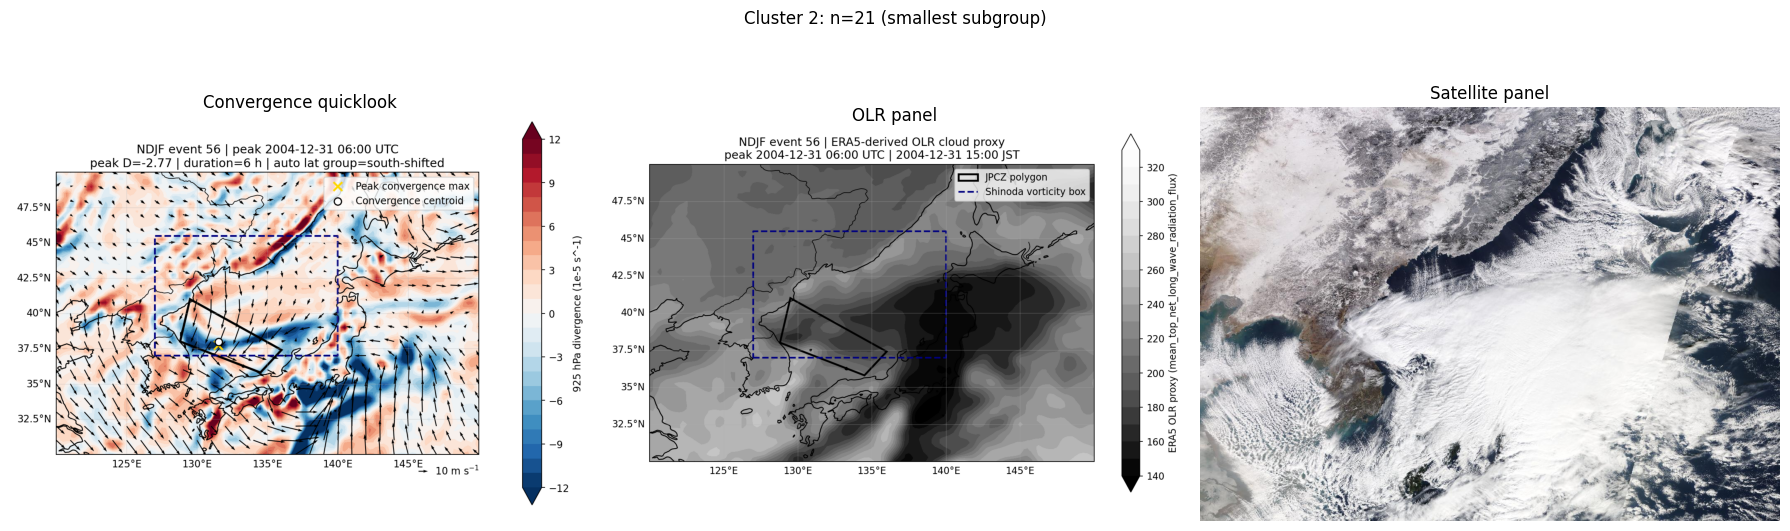

In [9]:

def display_representative_panels(representative_df: pd.DataFrame, *, per_cluster: int = 1):
    rows_to_show = representative_df.groupby("cluster_id", group_keys=False).head(per_cluster)
    for _, rep in rows_to_show.iterrows():
        print(rep["cluster_label"])
        print(
            f"catalog idx {int(rep['catalog_index'])} | UTC {pd.Timestamp(rep['event_peak_utc']):%Y-%m-%d %H:%M} | "
            f"JST {pd.Timestamp(rep['event_peak_jst']):%Y-%m-%d %H:%M} | centroid distance {rep['centroid_distance']:.3f}"
        )

        panel_specs = [
            ("Convergence quicklook", QUICKLOOK_DIR / rep["quicklook_name"], QUICKLOOK_DIR.name),
            ("OLR panel", OLR_DIR / rep["olr_name"], OLR_DIR.name),
        ]
        if pd.notna(rep["satellite_name"]) and rep["satellite_name"]:
            panel_specs.append(("Satellite panel", SATELLITE_DIR / rep["satellite_name"], SATELLITE_DIR.name))

        fig, axes = plt.subplots(1, len(panel_specs), figsize=(6 * len(panel_specs), 6))
        if len(panel_specs) == 1:
            axes = [axes]

        for ax, (panel_label, local_path, drive_subdir_name) in zip(axes, panel_specs):
            has_panel = ensure_local_copy(local_path, drive_subdir_name)
            if not has_panel:
                ax.axis("off")
                ax.set_title(f"{panel_label}\nmissing")
                continue
            image = mpimg.imread(local_path)
            ax.imshow(image)
            ax.axis("off")
            ax.set_title(panel_label)

        fig.suptitle(rep["cluster_label"], y=0.98)
        fig.tight_layout()
        plt.show()


display_representative_panels(
    representative_events_df,
    per_cluster=DISPLAY_REPRESENTATIVE_EVENTS_PER_CLUSTER,
)


In [10]:
required_globals = [
    "CLIMATOLOGY_PATH",
    "Z300_CLIMATOLOGY_PATH",
    "restore_from_drive_cache",
    "clustered_k3_df",
    "PRIMARY_CLUSTER_COLUMN",
    "cluster_label_df",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the setup/import cell, the Notebook 16 config/helper cell, and the cleaned-cluster context cell before the composite-build cell. "
        f"Missing globals: {missing_globals}"
    )

if not CLIMATOLOGY_PATH.exists():
    restore_from_drive_cache(CLIMATOLOGY_PATH)
if not Z300_CLIMATOLOGY_PATH.exists():
    restore_from_drive_cache(Z300_CLIMATOLOGY_PATH)

for path in [
    COMPOSITE_MEAN_PATH,
    COMPOSITE_STD_PATH,
    COMPOSITE_COUNT_PATH,
    COMPOSITE_EVENT_BOX_PATH,
    COMPOSITE_BOX_SUMMARY_PATH,
    COMPOSITE_MAP_BOX_PATH,
    COMPOSITE_DIFF_PATH,
    PARTIAL_STATUS_PATH,
]:
    if not path.exists():
        restore_from_drive_cache(path)

cluster_ids = sorted(clustered_k3_df[PRIMARY_CLUSTER_COLUMN].dropna().astype(int).unique())
cluster_meaning_df = cluster_label_df.copy()
cluster_evidence_specs = [
    {
        "feature": "hokkaido_min_z850_anomaly_tminus12_to_tplus12",
        "display_name": "Hokkaido minimum z850 anomaly over t-12/t0/t+12",
        "units": "gpm",
        "interpretation": "More negative values mean a deeper low/trough signal near Hokkaido.",
    },
    {
        "feature": "sea_of_japan_mean_vorticity_peak_925_russian_coastal_excluded",
        "display_name": "Sea of Japan mean 925 hPa vorticity at peak (Russian coastal exclusion)",
        "units": "1e-5 s^-1",
        "interpretation": "Larger positive values mean stronger cyclonic Sea of Japan circulation after the Russian-coastal exclusion.",
    },
    {
        "feature": "coastal_to_jpcz_mean_divergence_ratio_russian_coastal_excluded",
        "display_name": "Coastal-to-JPCZ mean signed-divergence ratio at peak (Russian coastal exclusion)",
        "units": "unitless",
        "interpretation": "When both regional means are negative, larger values mean the coastal box is more convergent relative to the polygon mean; here the Russian-coastal exclusion is applied before the ratio is computed.",
    },
    {
        "feature": "front_box_max_temp_gradient_850_tminus12_to_tplus12_russian_coastal_excluded",
        "display_name": "Front-box maximum |grad T850| over t-12/t0/t+12 (Russian coastal exclusion)",
        "units": "K (100 km)^-1",
        "interpretation": "Larger values mean stronger frontality/baroclinicity after the Russian-coastal exclusion.",
    },
]
cluster_medians_lookup = cluster_medians_df.copy()
cluster_medians_lookup.index = pd.Index([int(x) for x in cluster_medians_lookup.index], name="cluster_id")
cluster_evidence_rows = []
for spec in cluster_evidence_specs:
    feature = spec["feature"]
    row = {
        "feature": feature,
        "display_name": spec["display_name"],
        "units": spec["units"],
        "interpretation": spec["interpretation"],
    }
    for cluster_id in cluster_ids:
        row[f"cluster_{int(cluster_id)}_median"] = float(cluster_medians_lookup.loc[int(cluster_id), feature])
    cluster_evidence_rows.append(row)
cluster_evidence_df = pd.DataFrame(cluster_evidence_rows)
median_columns = [column for column in cluster_evidence_df.columns if column.endswith("_median")]
for column_name in median_columns:
    cluster_evidence_df[column_name] = cluster_evidence_df[column_name].round(2)
cluster_evidence_path = COMPOSITE_EXPORT_DIR / "cleaned_k2_cluster_feature_median_table.csv"
cluster_evidence_df.to_csv(cluster_evidence_path, index=False)
maybe_copy_to_drive(cluster_evidence_path)

field_display_names = {
    "divergence_925_peak": "925 hPa signed divergence at event peak (Russian coastal exclusion)",
    "z850_anomaly_min_tminus12_to_tplus12": "850 hPa z anomaly minimum over t-12/t0/t+12 (Russian coastal exclusion)",
    "temperature_gradient_850_max_tminus12_to_tplus12": "850 hPa |grad T| maximum over t-12/t0/t+12 (Russian coastal exclusion)",
    "vertical_moisture_flux_proxy_850_peak": "850 hPa vertical moisture-flux proxy at event peak (Russian coastal exclusion)",
    "wind_speed_300_peak": "300 hPa wind-speed isotachs at event peak",
    "z300_anomaly_peak": "300 hPa geopotential-height anomaly at event peak",
    "divergence_300_peak": "300 hPa signed divergence at event peak",
    "ageostrophic_divergence_300_peak": "300 hPa ageostrophic divergence at event peak",
    "ageostrophic_u_300_peak": "300 hPa ageostrophic zonal wind at event peak",
    "ageostrophic_v_300_peak": "300 hPa ageostrophic meridional wind at event peak",
}
field_units = {
    "divergence_925_peak": "1e-5 s^-1",
    "z850_anomaly_min_tminus12_to_tplus12": "gpm",
    "temperature_gradient_850_max_tminus12_to_tplus12": "K (100 km)^-1",
    "vertical_moisture_flux_proxy_850_peak": "1e-3 Pa s^-1",
    "wind_speed_300_peak": "m s^-1",
    "z300_anomaly_peak": "gpm",
    "divergence_300_peak": "1e-5 s^-1",
    "ageostrophic_divergence_300_peak": "1e-5 s^-1",
    "ageostrophic_u_300_peak": "m s^-1",
    "ageostrophic_v_300_peak": "m s^-1",
}
composite_field_definition_df = pd.DataFrame(
    [
        {
            "field": "divergence_925_peak",
            "label": field_display_names["divergence_925_peak"],
            "formula": "1e5 * (du/dx + dv/dy) on the objective low-level grid, then Russian-coastal exclusion, then embed on the working grid",
            "time_reduction": "event peak only (t0)",
            "source_fields": "925 hPa u and v winds",
            "units": field_units["divergence_925_peak"],
        },
        {
            "field": "z850_anomaly_min_tminus12_to_tplus12",
            "label": field_display_names["z850_anomaly_min_tminus12_to_tplus12"],
            "formula": "min[z850_event(t) - z850_monthly_climatology(month(t))] over t in {-12,0,+12} on the objective low-level grid, then Russian-coastal exclusion, then embed on the working grid",
            "time_reduction": "minimum over t-12, t0, t+12",
            "source_fields": "850 hPa geopotential height",
            "units": field_units["z850_anomaly_min_tminus12_to_tplus12"],
        },
        {
            "field": "temperature_gradient_850_max_tminus12_to_tplus12",
            "label": field_display_names["temperature_gradient_850_max_tminus12_to_tplus12"],
            "formula": "max[1e5 * sqrt((dT/dx)^2 + (dT/dy)^2)] over t in {-12,0,+12} on the objective low-level grid, then Russian-coastal exclusion, then embed on the working grid",
            "time_reduction": "maximum over t-12, t0, t+12",
            "source_fields": "850 hPa temperature",
            "units": field_units["temperature_gradient_850_max_tminus12_to_tplus12"],
        },
        {
            "field": "vertical_moisture_flux_proxy_850_peak",
            "label": field_display_names["vertical_moisture_flux_proxy_850_peak"],
            "formula": "-1e3 * q850 * omega850 on the objective low-level grid, then Russian-coastal exclusion, then embed on the working grid",
            "time_reduction": "event peak only (t0)",
            "source_fields": "850 hPa specific humidity and ERA5 pressure vertical velocity",
            "units": field_units["vertical_moisture_flux_proxy_850_peak"],
        },
        {
            "field": "wind_speed_300_peak",
            "label": field_display_names["wind_speed_300_peak"],
            "formula": "sqrt(u300^2 + v300^2) on the working grid",
            "time_reduction": "event peak only (t0)",
            "source_fields": "300 hPa u and v winds",
            "units": field_units["wind_speed_300_peak"],
        },
        {
            "field": "z300_anomaly_peak",
            "label": field_display_names["z300_anomaly_peak"],
            "formula": "z300_event - z300_monthly_climatology on the working grid",
            "time_reduction": "event peak only (t0)",
            "source_fields": "300 hPa geopotential height",
            "units": field_units["z300_anomaly_peak"],
        },
        {
            "field": "divergence_300_peak",
            "label": field_display_names["divergence_300_peak"],
            "formula": "1e5 * (du300/dx + dv300/dy) on the working grid",
            "time_reduction": "event peak only (t0)",
            "source_fields": "300 hPa u and v winds",
            "units": field_units["divergence_300_peak"],
        },
        {
            "field": "ageostrophic_divergence_300_peak",
            "label": field_display_names["ageostrophic_divergence_300_peak"],
            "formula": "1e5 * (du_ag/dx + dv_ag/dy), where u_ag = u300 - u_g and v_ag = v300 - v_g, on the working grid",
            "time_reduction": "event peak only (t0)",
            "source_fields": "300 hPa total wind and geopotential height",
            "units": field_units["ageostrophic_divergence_300_peak"],
        },
        {
            "field": "ageostrophic_u_300_peak",
            "label": field_display_names["ageostrophic_u_300_peak"],
            "formula": "u_ag = u300 - u_g on the working grid",
            "time_reduction": "event peak only (t0)",
            "source_fields": "300 hPa total wind and geopotential height",
            "units": field_units["ageostrophic_u_300_peak"],
        },
        {
            "field": "ageostrophic_v_300_peak",
            "label": field_display_names["ageostrophic_v_300_peak"],
            "formula": "v_ag = v300 - v_g on the working grid",
            "time_reduction": "event peak only (t0)",
            "source_fields": "300 hPa total wind and geopotential height",
            "units": field_units["ageostrophic_v_300_peak"],
        },
    ]
)
climatology_years = sorted(pd.to_datetime(clustered_k3_df["event_peak"]).dt.year.unique().tolist())
required_months = sorted(pd.to_datetime(clustered_k3_df["event_peak"]).dt.month.unique().tolist())
era5_runtime_ds = None


def load_or_update_climatology(path: Path, *, level: int, label: str, domain):
    global era5_runtime_ds
    if path.exists():
        climatology = xr.open_dataarray(path).load()
        cached_months = {int(month_value) for month_value in climatology["month"].values.tolist()}
    else:
        climatology = None
        cached_months = set()
    missing_months = sorted(set(required_months) - cached_months)
    if missing_months:
        print(f"Cached {label} climatology missing months: {missing_months}")
        print(f"Computing missing {label} climatology months one at a time and checkpointing each completed month to Drive.")
        era5_runtime_ds = open_arco_era5(chunks={"time": ERA5_TIME_CHUNK}) if era5_runtime_ds is None else era5_runtime_ds
        for month in missing_months:
            month_climatology = compute_monthly_geopotential_height_climatology(
                era5_runtime_ds,
                years=climatology_years,
                months=[month],
                domain=domain,
                level=level,
            )
            if climatology is None:
                climatology = month_climatology
            else:
                climatology = xr.concat([climatology, month_climatology], dim="month").sortby("month")
            climatology.to_netcdf(path)
            maybe_copy_to_drive(path)
            print(f"Checkpointed {label} climatology after month {month:02d}")
        climatology_source = "month-by-month checkpoints"
    else:
        climatology_source = "restored cached climatology"
    if climatology is None:
        raise RuntimeError(f"Unable to load or compute the {label} climatology.")
    return climatology, climatology_source


z850_climatology, z850_climatology_source = load_or_update_climatology(
    CLIMATOLOGY_PATH,
    level=850,
    label="Z850 objective-domain",
    domain=LOW_LEVEL_COMPOSITE_DOMAIN,
)
z300_climatology, z300_climatology_source = load_or_update_climatology(
    Z300_CLIMATOLOGY_PATH,
    level=300,
    label="Z300 working-domain",
    domain=UPPER_LEVEL_COMPOSITE_DOMAIN,
)

z850_climatology_summary_df = (
    z850_climatology.mean(dim=("latitude", "longitude"))
    .to_series()
    .rename("domain_mean_gpm")
    .reset_index()
)
z300_climatology_summary_df = (
    z300_climatology.mean(dim=("latitude", "longitude"))
    .to_series()
    .rename("domain_mean_gpm")
    .reset_index()
)

print("Composite field definitions used in Notebook 16")
display(composite_field_definition_df)
print("\nPrimary cleaned k=2 cluster labels derived from subgroup sizes")
display(cluster_meaning_df)
print("\nFeature-median table for the cleaned k=2 clusters")
display(cluster_evidence_df)
print(
    f"\nZ850 climatology source: {z850_climatology_source}; using the study-period event years represented in the cleaned catalog: "
    f"{climatology_years[0]}-{climatology_years[-1]} ({len(climatology_years)} years) on the objective low-level domain"
)
print("Required climatology months:", required_months)
display(z850_climatology_summary_df)
print(
    f"\nZ300 climatology source: {z300_climatology_source}; using the study-period event years represented in the cleaned catalog: "
    f"{climatology_years[0]}-{climatology_years[-1]} ({len(climatology_years)} years) on the wider working domain"
)
display(z300_climatology_summary_df)


def compute_event_primary_fields(ds: xr.Dataset, row: pd.Series, geometry_low=None, geometry_upper=None):
    def strip_nonspatial_coords(field: xr.DataArray, *, keep_dims=("latitude", "longitude", "offset_hours")) -> xr.DataArray:
        drop_coords = [coord_name for coord_name in field.coords if coord_name not in keep_dims]
        if drop_coords:
            field = field.reset_coords(names=drop_coords, drop=True)
        return field

    peak_time = pd.Timestamp(row["event_peak"])

    peak_snapshot_925 = load_snapshot(
        ds,
        peak_time,
        variables=("u_component_of_wind", "v_component_of_wind"),
        domain=LOW_LEVEL_COMPOSITE_DOMAIN,
        level=925,
    )
    if geometry_low is None:
        geometry_low = prepare_detection_geometry(
            peak_snapshot_925.longitude,
            peak_snapshot_925.latitude,
            JPCZ_POLYGON_VERTICES,
        )
    low_dx = geometry_low.dx
    low_dy = geometry_low.dy

    divergence_field = compute_divergence_field(
        peak_snapshot_925,
        dx=low_dx,
        dy=low_dy,
    )
    signed_divergence_field = strip_nonspatial_coords((divergence_field * 1e5).rename("divergence_925_peak"))
    keep_mask_925 = build_russian_coastal_keep_mask(signed_divergence_field)
    signed_divergence_field = signed_divergence_field.where(keep_mask_925)

    moisture_snapshot_850 = load_snapshot(
        ds,
        peak_time,
        variables=("specific_humidity", "vertical_velocity"),
        domain=LOW_LEVEL_COMPOSITE_DOMAIN,
        level=850,
    )
    keep_mask_850 = build_russian_coastal_keep_mask(
        strip_nonspatial_coords(moisture_snapshot_850["specific_humidity"].rename("specific_humidity_850"))
    )

    upper_snapshot_300 = load_snapshot(
        ds,
        peak_time,
        variables=("u_component_of_wind", "v_component_of_wind", "geopotential", "temperature"),
        domain=UPPER_LEVEL_COMPOSITE_DOMAIN,
        level=300,
    )
    if geometry_upper is None:
        geometry_upper = prepare_detection_geometry(
            upper_snapshot_300.longitude,
            upper_snapshot_300.latitude,
            JPCZ_POLYGON_VERTICES,
        )
    upper_dx = geometry_upper.dx
    upper_dy = geometry_upper.dy
    working_longitude = upper_snapshot_300.longitude
    working_latitude = upper_snapshot_300.latitude

    vertical_moisture_flux_proxy = strip_nonspatial_coords((
        -1000.0
        * moisture_snapshot_850["specific_humidity"]
        * moisture_snapshot_850["vertical_velocity"]
    ).rename("vertical_moisture_flux_proxy_850_peak")).where(keep_mask_850)
    vertical_moisture_flux_proxy.attrs["units"] = "1e-3 Pa s^-1"
    vertical_moisture_flux_proxy.attrs["long_name"] = (
        "Positive values indicate stronger moist ascent proxy (-q * omega) at 850 hPa after the Russian-coastal exclusion; "
        "negative values indicate moist subsidence proxy."
    )
    vertical_moisture_flux_proxy = embed_on_working_grid(vertical_moisture_flux_proxy, working_longitude, working_latitude)

    wind_speed_300_peak = strip_nonspatial_coords(compute_wind_speed_field(upper_snapshot_300).rename("wind_speed_300_peak"))
    wind_speed_300_peak.attrs["long_name"] = "300 hPa wind speed magnitude"

    z300 = strip_nonspatial_coords(compute_geopotential_height_field(upper_snapshot_300))
    z300_anomaly_peak = strip_nonspatial_coords((z300 - z300_climatology.sel(month=peak_time.month)).rename("z300_anomaly_peak"))
    z300_anomaly_peak.attrs["units"] = "gpm"

    divergence_300_peak = strip_nonspatial_coords((
        compute_divergence_field(upper_snapshot_300, dx=upper_dx, dy=upper_dy) * 1e5
    ).rename("divergence_300_peak"))
    divergence_300_peak.attrs["units"] = "1e-5 s^-1"

    ageostrophic_u_300_peak, ageostrophic_v_300_peak = compute_ageostrophic_wind_fields(
        upper_snapshot_300,
        geopotential_height=z300,
        dx=upper_dx,
        dy=upper_dy,
    )
    ageostrophic_u_300_peak = strip_nonspatial_coords(ageostrophic_u_300_peak.rename("ageostrophic_u_300_peak"))
    ageostrophic_v_300_peak = strip_nonspatial_coords(ageostrophic_v_300_peak.rename("ageostrophic_v_300_peak"))
    ageostrophic_u_300_peak.attrs["units"] = "m s^-1"
    ageostrophic_v_300_peak.attrs["units"] = "m s^-1"

    ageostrophic_divergence_300_peak = strip_nonspatial_coords((
        compute_ageostrophic_divergence_field(
            upper_snapshot_300,
            geopotential_height=z300,
            dx=upper_dx,
            dy=upper_dy,
        )
        * 1e5
    ).rename("ageostrophic_divergence_300_peak"))
    ageostrophic_divergence_300_peak.attrs["units"] = "1e-5 s^-1"

    z850_anomaly_stack = []
    temp_gradient_stack = []
    for offset in SYNOPTIC_OFFSETS:
        synoptic_time = peak_time + pd.Timedelta(hours=offset)
        synoptic_snapshot_850 = load_offset_snapshot(
            ds,
            peak_time,
            offset_hours=offset,
            variables=("geopotential", "temperature"),
            domain=LOW_LEVEL_COMPOSITE_DOMAIN,
            level=850,
        )
        z850 = compute_geopotential_height_field(synoptic_snapshot_850)
        z850_anomaly = strip_nonspatial_coords((z850 - z850_climatology.sel(month=synoptic_time.month))).where(keep_mask_850).expand_dims(offset_hours=[offset])
        z850_anomaly_stack.append(z850_anomaly)

        temp_gradient = compute_temperature_gradient_magnitude(synoptic_snapshot_850)
        temp_gradient_display = strip_nonspatial_coords(
            temp_gradient * float(temp_gradient.attrs.get("display_scale_factor", 1.0))
        ).where(keep_mask_850).expand_dims(offset_hours=[offset])
        temp_gradient_stack.append(temp_gradient_display)

    z850_anomaly_min = xr.concat(z850_anomaly_stack, dim="offset_hours").min(dim="offset_hours", skipna=True)
    z850_anomaly_min = z850_anomaly_min.rename("z850_anomaly_min_tminus12_to_tplus12")
    z850_anomaly_min = embed_on_working_grid(z850_anomaly_min, working_longitude, working_latitude)

    temp_gradient_max = xr.concat(temp_gradient_stack, dim="offset_hours").max(dim="offset_hours", skipna=True)
    temp_gradient_max = temp_gradient_max.rename("temperature_gradient_850_max_tminus12_to_tplus12")
    temp_gradient_max = embed_on_working_grid(temp_gradient_max, working_longitude, working_latitude)

    signed_divergence_field = embed_on_working_grid(signed_divergence_field, working_longitude, working_latitude)

    event_ds = xr.Dataset(
        {
            "divergence_925_peak": signed_divergence_field,
            "z850_anomaly_min_tminus12_to_tplus12": z850_anomaly_min,
            "temperature_gradient_850_max_tminus12_to_tplus12": temp_gradient_max,
            "vertical_moisture_flux_proxy_850_peak": vertical_moisture_flux_proxy,
            "wind_speed_300_peak": wind_speed_300_peak,
            "z300_anomaly_peak": z300_anomaly_peak,
            "divergence_300_peak": divergence_300_peak,
            "ageostrophic_divergence_300_peak": ageostrophic_divergence_300_peak,
            "ageostrophic_u_300_peak": ageostrophic_u_300_peak,
            "ageostrophic_v_300_peak": ageostrophic_v_300_peak,
        }
    )
    return event_ds, geometry_low, geometry_upper


if all(path.exists() for path in [COMPOSITE_MEAN_PATH, COMPOSITE_STD_PATH, COMPOSITE_COUNT_PATH, COMPOSITE_EVENT_BOX_PATH, COMPOSITE_BOX_SUMMARY_PATH, COMPOSITE_MAP_BOX_PATH, COMPOSITE_DIFF_PATH]) and not FORCE_REBUILD_CLUSTER_COMPOSITES:
    composite_mean_ds = xr.open_dataset(COMPOSITE_MEAN_PATH).load()
    composite_std_ds = xr.open_dataset(COMPOSITE_STD_PATH).load()
    composite_count_ds = xr.open_dataset(COMPOSITE_COUNT_PATH).load()
    composite_diff_ds = xr.open_dataset(COMPOSITE_DIFF_PATH).load()
    event_box_df = pd.read_csv(COMPOSITE_EVENT_BOX_PATH)
    cluster_box_summary_df = pd.read_csv(COMPOSITE_BOX_SUMMARY_PATH)
    composite_map_box_df = pd.read_csv(COMPOSITE_MAP_BOX_PATH)
    print("Loaded cached cleaned working-domain composite products")
else:
    ds = era5_runtime_ds if era5_runtime_ds is not None else open_arco_era5(chunks={"time": ERA5_TIME_CHUNK})
    geometry_low = None
    geometry_upper = None
    cluster_mean_datasets = []
    cluster_std_datasets = []
    cluster_count_datasets = []
    event_box_records_all = []
    partial_status_lookup = {}

    for cluster_id in cluster_ids:
        cluster_members = clustered_k3_df.loc[clustered_k3_df[PRIMARY_CLUSTER_COLUMN] == cluster_id].copy()
        total_events = len(cluster_members)
        partial_accumulator_path = COMPOSITE_EXPORT_DIR / f"cleaned_k2_cluster_{int(cluster_id)}_field_accumulators.nc"
        partial_box_path = COMPOSITE_EXPORT_DIR / f"cleaned_k2_cluster_{int(cluster_id)}_event_box_means_partial.csv"
        if not partial_accumulator_path.exists():
            restore_from_drive_cache(partial_accumulator_path)
        if not partial_box_path.exists():
            restore_from_drive_cache(partial_box_path)

        accumulator_ds = None
        processed_events = 0
        cluster_box_records = []
        if partial_accumulator_path.exists() and not FORCE_REBUILD_CLUSTER_COMPOSITES:
            with xr.open_dataset(partial_accumulator_path) as partial_ds_open:
                partial_ds = partial_ds_open.load()
            cached_total_events = int(partial_ds.attrs.get("total_events", total_events))
            cached_processed_events = int(partial_ds.attrs.get("processed_events", 0))
            if cached_total_events == total_events and cached_processed_events > 0:
                accumulator_ds = partial_ds
                processed_events = min(cached_processed_events, total_events)
                if partial_box_path.exists():
                    cluster_box_records = pd.read_csv(partial_box_path).to_dict("records")
                print(
                    f"Restored partial cleaned composite checkpoint for cluster {cluster_id}: {processed_events}/{total_events} events"
                )
            elif cached_total_events != total_events:
                print(
                    f"Ignoring stale partial checkpoint for cluster {cluster_id}: cached total {cached_total_events} != current total {total_events}"
                )

        if processed_events >= total_events and accumulator_ds is not None:
            cluster_mean_ds, cluster_std_ds, cluster_count_ds = finalize_accumulator_dataset(accumulator_ds)
            cluster_mean_datasets.append(cluster_mean_ds.expand_dims(cluster_id=[cluster_id]))
            cluster_std_datasets.append(cluster_std_ds.expand_dims(cluster_id=[cluster_id]))
            cluster_count_datasets.append(cluster_count_ds.expand_dims(cluster_id=[cluster_id]))
            event_box_records_all.extend(cluster_box_records)
            partial_status_lookup[cluster_id] = {
                "cluster_id": int(cluster_id),
                "cluster_label": CLUSTER_LABELS[int(cluster_id)],
                "processed_events": int(total_events),
                "total_events": int(total_events),
                "complete": True,
            }
            write_partial_status(partial_status_lookup)
            continue

        remaining_members = cluster_members.iloc[processed_events:]
        for offset, (_, row) in enumerate(remaining_members.iterrows(), start=1):
            event_number = processed_events + offset
            event_ds, geometry_low, geometry_upper = compute_event_primary_fields(ds, row, geometry_low=geometry_low, geometry_upper=geometry_upper)
            if accumulator_ds is None:
                accumulator_ds = initialize_accumulator_dataset(event_ds)
            else:
                accumulator_ds = update_accumulator_dataset(accumulator_ds, event_ds)

            for field_name in REPORTABLE_COMPOSITE_FIELDS:
                field = event_ds[field_name]
                for box_name, box in BOXES.items():
                    cluster_box_records.append(
                        {
                            "cluster_id": int(cluster_id),
                            "cluster_label": CLUSTER_LABELS[int(cluster_id)],
                            "catalog_index": int(row.name),
                            "event_peak": pd.Timestamp(row["event_peak"]),
                            "field": field_name,
                            "field_label": field_display_names[field_name],
                            "box_name": box_name,
                            "box_weighted_mean": lat_weighted_box_mean(field, box),
                        }
                    )

            should_checkpoint = PROGRESS_EVERY > 0 and (event_number % PROGRESS_EVERY == 0 or event_number == total_events)
            if should_checkpoint:
                print(
                    f"Cleaned working-domain composite accumulation for cluster {cluster_id}: {event_number}/{total_events} events"
                )
                write_partial_accumulator_checkpoint(
                    accumulator_ds,
                    cluster_id=int(cluster_id),
                    processed_events=int(event_number),
                    total_events=int(total_events),
                    partial_path=partial_accumulator_path,
                )
                pd.DataFrame(cluster_box_records).to_csv(partial_box_path, index=False)
                maybe_copy_to_drive(partial_box_path)
                partial_status_lookup[cluster_id] = {
                    "cluster_id": int(cluster_id),
                    "cluster_label": CLUSTER_LABELS[int(cluster_id)],
                    "processed_events": int(event_number),
                    "total_events": int(total_events),
                    "complete": bool(event_number == total_events),
                }
                write_partial_status(partial_status_lookup)

        if accumulator_ds is None:
            raise RuntimeError(f"No composite fields were accumulated for cluster {cluster_id}")

        write_partial_accumulator_checkpoint(
            accumulator_ds,
            cluster_id=int(cluster_id),
            processed_events=int(total_events),
            total_events=int(total_events),
            partial_path=partial_accumulator_path,
        )
        pd.DataFrame(cluster_box_records).to_csv(partial_box_path, index=False)
        maybe_copy_to_drive(partial_box_path)
        partial_status_lookup[cluster_id] = {
            "cluster_id": int(cluster_id),
            "cluster_label": CLUSTER_LABELS[int(cluster_id)],
            "processed_events": int(total_events),
            "total_events": int(total_events),
            "complete": True,
        }
        write_partial_status(partial_status_lookup)

        cluster_mean_ds, cluster_std_ds, cluster_count_ds = finalize_accumulator_dataset(accumulator_ds)
        cluster_mean_datasets.append(cluster_mean_ds.expand_dims(cluster_id=[cluster_id]))
        cluster_std_datasets.append(cluster_std_ds.expand_dims(cluster_id=[cluster_id]))
        cluster_count_datasets.append(cluster_count_ds.expand_dims(cluster_id=[cluster_id]))
        event_box_records_all.extend(cluster_box_records)

    composite_mean_ds = xr.concat(cluster_mean_datasets, dim="cluster_id")
    composite_std_ds = xr.concat(cluster_std_datasets, dim="cluster_id")
    composite_count_ds = xr.concat(cluster_count_datasets, dim="cluster_id")

    event_box_df = pd.DataFrame(event_box_records_all)
    cluster_box_summary_df = (
        event_box_df.groupby(["cluster_id", "cluster_label", "field", "field_label", "box_name"], dropna=False)["box_weighted_mean"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .reset_index()
        .rename(columns={
            "count": "n_events",
            "mean": "mean_event_box_weighted_mean",
            "median": "median_event_box_weighted_mean",
            "std": "std_event_box_weighted_mean",
            "min": "min_event_box_weighted_mean",
            "max": "max_event_box_weighted_mean",
        })
    )

    composite_map_box_records = []
    for cluster_id in cluster_ids:
        for field_name in ALL_COMPOSITE_FIELDS:
            field = composite_mean_ds[field_name].sel(cluster_id=cluster_id)
            count_field = composite_count_ds[field_name].sel(cluster_id=cluster_id)
            for box_name, box in BOXES.items():
                box_counts = count_field.sel(
                    longitude=slice(box.lon_min, box.lon_max),
                    latitude=slice(box.lat_max, box.lat_min),
                )
                composite_map_box_records.append(
                    {
                        "cluster_id": int(cluster_id),
                        "cluster_label": CLUSTER_LABELS[int(cluster_id)],
                        "field": field_name,
                        "field_label": field_display_names[field_name],
                        "box_name": box_name,
                        "box_weighted_mean_from_composite_map": lat_weighted_box_mean(field, box),
                        "min_gridcell_count_in_box": int(box_counts.min().values),
                        "max_gridcell_count_in_box": int(box_counts.max().values),
                    }
                )
    composite_map_box_df = pd.DataFrame(composite_map_box_records)

    diff_datasets = []
    for left_cluster in cluster_ids:
        for right_cluster in cluster_ids:
            if int(left_cluster) <= int(right_cluster):
                continue
            diff_label = f"cluster_{int(left_cluster)}_minus_{int(right_cluster)}"
            diff_ds = (composite_mean_ds.sel(cluster_id=left_cluster) - composite_mean_ds.sel(cluster_id=right_cluster)).expand_dims(pair_label=[diff_label])
            diff_datasets.append(diff_ds)
    if diff_datasets:
        composite_diff_ds = xr.concat(diff_datasets, dim="pair_label")
    else:
        composite_diff_ds = xr.Dataset()

    composite_mean_ds.to_netcdf(COMPOSITE_MEAN_PATH)
    composite_std_ds.to_netcdf(COMPOSITE_STD_PATH)
    composite_count_ds.to_netcdf(COMPOSITE_COUNT_PATH)
    if diff_datasets:
        composite_diff_ds.to_netcdf(COMPOSITE_DIFF_PATH)
    event_box_df.to_csv(COMPOSITE_EVENT_BOX_PATH, index=False)
    cluster_box_summary_df.to_csv(COMPOSITE_BOX_SUMMARY_PATH, index=False)
    composite_map_box_df.to_csv(COMPOSITE_MAP_BOX_PATH, index=False)

    for path in [
        COMPOSITE_MEAN_PATH,
        COMPOSITE_STD_PATH,
        COMPOSITE_COUNT_PATH,
        COMPOSITE_EVENT_BOX_PATH,
        COMPOSITE_BOX_SUMMARY_PATH,
        COMPOSITE_MAP_BOX_PATH,
    ]:
        maybe_copy_to_drive(path)
    if diff_datasets:
        maybe_copy_to_drive(COMPOSITE_DIFF_PATH)

print("Primary cleaned composite mean fields")
display(composite_mean_ds)
print("\nCleaned cluster composite box-summary table")
display(cluster_box_summary_df.head(18))


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster_feature_median_table.csv
Composite field definitions used in Notebook 16


,field,label,formula,time_reduction,source_fields,units
0,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,1e5 * (du/dx + dv/dy) on the objective low-lev...,event peak only (t0),925 hPa u and v winds,1e-5 s^-1
1,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,min[z850_event(t) - z850_monthly_climatology(m...,"minimum over t-12, t0, t+12",850 hPa geopotential height,gpm
2,temperature_gradient_850_max_tminus12_to_tplus12,850 hPa |grad T| maximum over t-12/t0/t+12 (Ru...,max[1e5 * sqrt((dT/dx)^2 + (dT/dy)^2)] over t ...,"maximum over t-12, t0, t+12",850 hPa temperature,K (100 km)^-1
3,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,-1e3 * q850 * omega850 on the objective low-le...,event peak only (t0),850 hPa specific humidity and ERA5 pressure ve...,1e-3 Pa s^-1
4,wind_speed_300_peak,300 hPa wind-speed isotachs at event peak,sqrt(u300^2 + v300^2) on the working grid,event peak only (t0),300 hPa u and v winds,m s^-1
5,z300_anomaly_peak,300 hPa geopotential-height anomaly at event peak,z300_event - z300_monthly_climatology on the w...,event peak only (t0),300 hPa geopotential height,gpm
6,divergence_300_peak,300 hPa signed divergence at event peak,1e5 * (du300/dx + dv300/dy) on the working grid,event peak only (t0),300 hPa u and v winds,1e-5 s^-1
7,ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,"1e5 * (du_ag/dx + dv_ag/dy), where u_ag = u300...",event peak only (t0),300 hPa total wind and geopotential height,1e-5 s^-1
8,ageostrophic_u_300_peak,300 hPa ageostrophic zonal wind at event peak,u_ag = u300 - u_g on the working grid,event peak only (t0),300 hPa total wind and geopotential height,m s^-1
9,ageostrophic_v_300_peak,300 hPa ageostrophic meridional wind at event ...,v_ag = v300 - v_g on the working grid,event peak only (t0),300 hPa total wind and geopotential height,m s^-1



Primary cleaned k=2 cluster labels derived from subgroup sizes


,cluster_id,n_events,size_rank,size_descriptor,cluster_label
0,1,180,1,largest subgroup,Cluster 1: n=180 (largest subgroup)
1,2,21,2,smallest subgroup,Cluster 2: n=21 (smallest subgroup)



Feature-median table for the cleaned k=2 clusters


...

,month,domain_mean_gpm
0,1,8848.428711
1,2,8870.958984
2,11,9091.769531
3,12,8914.948242


Restored partial cleaned composite checkpoint for cluster 1: 60/180 events
Cleaned working-domain composite accumulation for cluster 1: 70/180 events
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster_1_field_accumulators.nc
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster_1_event_box_means_partial.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_working_domain_cluster_composite_partial_status.csv
Cleaned working-domain composite accumulation for cluster 1: 80/180 events
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster_1_field_accumulators.nc
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster_1_event_box_means_partial.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_working_domain_cluster_composite_partial_status.csv
Cleaned working-domain composite accumulation for cluster 1: 90/180 events
Copied to Drive: /content/driv

<xarray.Dataset> Size: 2MB
Dimensions:                                           (cluster_id: 2,
                                                       latitude: 81,
                                                       longitude: 121)
Coordinates:
  * cluster_id                                        (cluster_id) int64 16B 1 2
  * latitude                                          (latitude) float32 324B ...
  * longitude                                         (longitude) float32 484B ...
Data variables:
    divergence_925_peak                               (cluster_id, latitude, longitude) float64 157kB ...
    z850_anomaly_min_tminus12_to_tplus12              (cluster_id, latitude, longitude) float64 157kB ...
    temperature_gradient_850_max_tminus12_to_tplus12  (cluster_id, latitude, longitude) float64 157kB ...
    vertical_moisture_flux_proxy_850_peak             (cluster_id, latitude, longitude) float64 157kB ...
    wind_speed_300_peak                               (cluster_id, latitude, longitude) float64 157kB ...
    z300_anomaly_peak                                 (cluster_id, latitude, longitude) float64 157kB ...
    divergence_300_peak                               (cluster_id, latitude, longitude) float64 157kB ...
    ageostrophic_divergence_300_peak                  (cluster_id, latitude, longitude) float64 157kB ...
    ageostrophic_u_300_peak                           (cluster_id, latitude, longitude) float64 157kB ...
    ageostrophic_v_300_peak                           (cluster_id, latitude, longitude) float64 157kB ...


Cleaned cluster composite box-summary table


,cluster_id,cluster_label,field,field_label,box_name,n_events,mean_event_box_weighted_mean,median_event_box_weighted_mean,std_event_box_weighted_mean,min_event_box_weighted_mean,max_event_box_weighted_mean
0,1,Cluster 1: n=180 (largest subgroup),ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,Coastal Japan,180,0.456356,0.311641,0.910108,-1.473740,3.429426
1,1,Cluster 1: n=180 (largest subgroup),ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,Hokkaido,180,0.508327,0.254701,0.989351,-1.668972,4.807727
2,1,Cluster 1: n=180 (largest subgroup),ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,Hokkaido front,180,0.577720,0.389233,0.693303,-0.702658,3.735876
3,1,Cluster 1: n=180 (largest subgroup),ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,Pacific east of Japan,180,0.546927,0.571553,0.883470,-1.522530,3.962816
4,1,Cluster 1: n=180 (largest subgroup),ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,Pacific front,180,0.546927,0.571553,0.883470,-1.522530,3.962816
5,1,Cluster 1: n=180 (largest subgroup),ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,Sea of Japan,180,0.406744,0.234169,0.719120,-0.810914,3.216381
6,1,Cluster 1: n=180 (largest subgroup),divergence_300_peak,300 hPa signed divergence at event peak,Coastal Japan,180,0.337630,0.162287,0.871484,-1.565228,3.179177
7,1,Cluster 1: n=180 (largest subgroup),divergence_300_peak,300 hPa signed divergence at event peak,Hokkaido,180,0.483485,0.223819,0.980288,-1.717676,4.772804
8,1,Cluster 1: n=180 (largest subgroup),divergence_300_peak,300 hPa signed divergence at event peak,Hokkaido front,180,0.537803,0.345056,0.679192,-0.680054,3.683332
9,1,Cluster 1: n=180 (largest subgroup),divergence_300_peak,300 hPa signed divergence at event peak,Pacific east of Japan,180,0.438524,0.417427,0.853678,-1.559349,3.868863


In [ ]:
required_globals = [
    "composite_mean_ds",
    "composite_count_ds",
    "cluster_ids",
    "cluster_event_counts",
    "CLUSTER_MAP_LABELS",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the Notebook 16 composite-build cell before the plotting cell. "
        f"Missing globals: {missing_globals}"
    )

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

DIVERGENCE_925_COMPOSITE_LIMIT = 20.0
DIVERGENCE_925_COMPOSITE_STEP = 2.0
DIVERGENCE_925_DIFF_LIMIT = 10.0
DIVERGENCE_925_DIFF_STEP = 1.0
MOISTURE_PROXY_LEVEL_STEP = 0.05
WIND_SPEED_300_LEVEL_STEP = 5.0
WIND_SPEED_300_DIFF_STEP = 2.5

primary_field_specs = [
    {
        "field": "divergence_925_peak",
        "title": "925 hPa signed-divergence composite",
        "subtitle": "Pointwise mean of raw signed 1e5 × (du/dx + dv/dy) at event peak after the Russian-coastal exclusion (negative = convergence; positive = divergence)",
        "cmap": "RdBu_r",
        "extend": "both",
        "cbar": "Signed divergence [1e-5 s^-1]",
    },
    {
        "field": "z850_anomaly_min_tminus12_to_tplus12",
        "title": "850 hPa geopotential-height anomaly composite",
        "subtitle": "Pointwise mean of the event-level minimum anomaly over t-12, t0, and t+12 after the Russian-coastal exclusion",
        "cmap": "RdBu_r",
        "extend": "both",
        "cbar": "Z850 anomaly [gpm]",
    },
    {
        "field": "temperature_gradient_850_max_tminus12_to_tplus12",
        "title": "850 hPa temperature-gradient composite",
        "subtitle": "Pointwise mean of the event-level maximum |grad T850| over t-12, t0, and t+12 after the Russian-coastal exclusion",
        "cmap": "viridis",
        "extend": "max",
        "cbar": "|grad T850| [K (100 km)^-1]",
    },
]

additional_field_specs = [
    {
        "field": "vertical_moisture_flux_proxy_850_peak",
        "title": "850 hPa q × (−ω) moisture-flux proxy composite",
        "subtitle": "Pointwise mean of 1e-3 × q850 × (−ω850) at event peak after the Russian-coastal exclusion (positive = moist-ascent proxy; negative = moist subsidence)",
        "cmap": "BrBG",
        "extend": "both",
        "cbar": "q × (−ω) proxy [1e-3 Pa s^-1]",
    },
    {
        "field": "wind_speed_300_peak",
        "title": "300 hPa wind-speed composite",
        "subtitle": "Working-domain pointwise mean isotachs from |V300| = sqrt(u300^2 + v300^2) at event peak",
        "cmap": "plasma",
        "extend": "max",
        "cbar": "300 hPa wind speed [m s^-1]",
    },
    {
        "field": "z300_anomaly_peak",
        "title": "300 hPa geopotential-height anomaly composite",
        "subtitle": "Working-domain pointwise mean of z300_event - z300_monthly_climatology at event peak",
        "cmap": "RdBu_r",
        "extend": "both",
        "cbar": "Z300 anomaly [gpm]",
    },
    {
        "field": "divergence_300_peak",
        "title": "300 hPa signed-divergence composite",
        "subtitle": "Working-domain pointwise mean of raw signed 1e5 × (du300/dx + dv300/dy) at event peak",
        "cmap": "RdBu_r",
        "extend": "both",
        "cbar": "300 hPa signed divergence [1e-5 s^-1]",
    },
    {
        "field": "ageostrophic_divergence_300_peak",
        "title": "300 hPa ageostrophic-divergence composite",
        "subtitle": "Working-domain pointwise mean of 1e5 × (du_ag/dx + dv_ag/dy) at event peak",
        "cmap": "RdBu_r",
        "extend": "both",
        "cbar": "300 hPa ageostrophic divergence [1e-5 s^-1]",
    },
]


def finite_field_values(field: xr.DataArray) -> np.ndarray:
    values = np.asarray(field.values, dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return np.array([0.0], dtype=float)
    return finite



def robust_quantile_limits(values: np.ndarray, *, lower_q: float = 0.01, upper_q: float = 0.99) -> tuple[float, float]:
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return 0.0, 0.0
    lower = float(np.nanquantile(finite, lower_q))
    upper = float(np.nanquantile(finite, upper_q))
    return lower, upper



def robust_abs_limit(values: np.ndarray, *, upper_q: float = 0.99) -> float:
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return 0.0
    return float(np.nanquantile(np.abs(finite), upper_q))



def rounded_limit(value: float, step: float, *, minimum: float = 0.0) -> float:
    if not np.isfinite(value):
        value = minimum
    return max(minimum, step * np.ceil(float(value) / step))



def choose_nice_step(data_span: float, *, target_bins: int = 24, candidates: tuple[float, ...] = (0.05, 0.10, 0.20, 0.25, 0.50, 1.00, 2.00, 5.00)) -> float:
    raw_step = max(float(data_span) / max(target_bins, 1), candidates[0])
    for step in candidates:
        if step >= raw_step:
            return step
    return candidates[-1]



def build_moisture_levels(field: xr.DataArray, *, difference: bool = False) -> np.ndarray:
    values = finite_field_values(field)
    if difference:
        min_limit = 0.30
        limit_raw = max(robust_abs_limit(values, upper_q=0.99), min_limit)
        step = choose_nice_step(2.0 * limit_raw, target_bins=24)
        limit = rounded_limit(limit_raw, step, minimum=min_limit)
        return np.arange(-limit, limit + step * 0.5, step)

    lower_raw, upper_raw = robust_quantile_limits(values, lower_q=0.01, upper_q=0.99)
    lower_limit = min(lower_raw, -0.05)
    upper_limit = max(upper_raw, 0.60)
    step = choose_nice_step(upper_limit - lower_limit, target_bins=24)
    lower = step * np.floor(lower_limit / step)
    upper = rounded_limit(upper_limit, step, minimum=0.60)
    if upper <= lower:
        upper = lower + (4 * step)
    return np.arange(lower, upper + step * 0.5, step)



def build_levels(field_name: str, *, source_ds: xr.Dataset | None = None, difference: bool = False) -> np.ndarray:
    if source_ds is None:
        source_ds = composite_diff_ds if difference else composite_mean_ds
    field = source_ds[field_name]
    values = finite_field_values(field)

    if field_name == "divergence_925_peak":
        limit = DIVERGENCE_925_DIFF_LIMIT if difference else DIVERGENCE_925_COMPOSITE_LIMIT
        step = DIVERGENCE_925_DIFF_STEP if difference else DIVERGENCE_925_COMPOSITE_STEP
        return np.arange(-limit, limit + step * 0.5, step)

    if field_name == "vertical_moisture_flux_proxy_850_peak":
        return build_moisture_levels(field, difference=difference)

    if field_name == "temperature_gradient_850_max_tminus12_to_tplus12":
        if difference:
            return np.arange(-3.0, 3.0 + 0.125, 0.25)
        upper = rounded_limit(np.max(values), 0.5, minimum=6.0)
        return np.arange(0.0, upper + 0.25, 0.5)

    if field_name == "z850_anomaly_min_tminus12_to_tplus12":
        step = 10.0
        min_limit = 80.0 if difference else 120.0
        limit = rounded_limit(np.max(np.abs(values)), step, minimum=min_limit)
        return np.arange(-limit, limit + step * 0.5, step)

    if field_name == "z300_anomaly_peak":
        step = 20.0
        min_limit = 120.0 if difference else 180.0
        limit = rounded_limit(np.max(np.abs(values)), step, minimum=min_limit)
        return np.arange(-limit, limit + step * 0.5, step)

    if field_name in {"divergence_300_peak", "ageostrophic_divergence_300_peak"}:
        step = 0.25 if difference else 0.5
        min_limit = 3.0 if difference else 4.0
        limit = rounded_limit(np.max(np.abs(values)), step, minimum=min_limit)
        return np.arange(-limit, limit + step * 0.5, step)

    if field_name == "wind_speed_300_peak":
        if difference:
            limit = rounded_limit(np.max(np.abs(values)), WIND_SPEED_300_DIFF_STEP, minimum=15.0)
            return np.arange(-limit, limit + WIND_SPEED_300_DIFF_STEP * 0.5, WIND_SPEED_300_DIFF_STEP)
        upper = rounded_limit(np.max(values), WIND_SPEED_300_LEVEL_STEP, minimum=60.0)
        return np.arange(0.0, upper + WIND_SPEED_300_LEVEL_STEP * 0.5, WIND_SPEED_300_LEVEL_STEP)

    max_abs = rounded_limit(np.max(np.abs(values)), 1.0, minimum=1.0)
    return np.arange(-max_abs, max_abs + 0.5, 1.0)



def coordinate_edges(coord_values: np.ndarray) -> np.ndarray:
    coord_values = np.asarray(coord_values, dtype=float)
    if coord_values.ndim != 1:
        raise ValueError("Expected a 1D coordinate array when building pcolormesh edges.")
    if coord_values.size == 1:
        half_step = 0.125
        return np.array([coord_values[0] - half_step, coord_values[0] + half_step], dtype=float)
    diffs = np.diff(coord_values)
    if np.any(diffs == 0.0):
        raise ValueError("Coordinate array contains repeated values, so cell edges are ambiguous.")
    edges = np.empty(coord_values.size + 1, dtype=float)
    edges[1:-1] = 0.5 * (coord_values[:-1] + coord_values[1:])
    edges[0] = coord_values[0] - 0.5 * diffs[0]
    edges[-1] = coord_values[-1] + 0.5 * diffs[-1]
    return edges



def draw_scalar_pcolormesh(ax, field: xr.DataArray, *, cmap_name: str, levels: np.ndarray, extend: str = "neither"):
    lon_edges = coordinate_edges(field.longitude.values)
    lat_edges = coordinate_edges(field.latitude.values)
    n_level_bins = max(len(levels) - 1, 1)
    n_extend_bins = {"neither": 0, "min": 1, "max": 1, "both": 2}.get(extend, 0)
    cmap = plt.get_cmap(cmap_name).resampled(n_level_bins + n_extend_bins)
    norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, clip=False, extend=extend)
    return ax.pcolormesh(
        lon_edges,
        lat_edges,
        field.values,
        cmap=cmap,
        norm=norm,
        shading="flat",
        transform=ccrs.PlateCarree(),
        linewidth=0.0,
        antialiased=False,
        snap=True,
    )



def add_base_map_features(ax, plot_domain):
    ax.set_extent(
        [plot_domain.lon_min, plot_domain.lon_max, plot_domain.lat_min, plot_domain.lat_max],
        crs=ccrs.PlateCarree(),
    )
    ax.coastlines(resolution="50m", linewidth=0.9)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
    ax.add_feature(cfeature.LAND, facecolor="#f2f2f2", alpha=0.6)
    gl = ax.gridlines(draw_labels=True, linewidth=0.25, alpha=0.35)
    gl.top_labels = False
    gl.right_labels = False
    return gl



def build_quiver_slices(field: xr.DataArray):
    lon_stride = max(1, int(np.ceil(field.sizes["longitude"] / 18)))
    lat_stride = max(1, int(np.ceil(field.sizes["latitude"] / 12)))
    return slice(None, None, lon_stride), slice(None, None, lat_stride)



def overlay_vector_field(
    ax,
    u_field: xr.DataArray,
    v_field: xr.DataArray,
    *,
    color: str,
    scale: float,
    width: float = 0.0022,
    headwidth: float = 3.2,
):
    lon_slice, lat_slice = build_quiver_slices(u_field)
    return ax.quiver(
        u_field.longitude.values[lon_slice],
        u_field.latitude.values[lat_slice],
        u_field.values[lat_slice, lon_slice],
        v_field.values[lat_slice, lon_slice],
        color=color,
        scale=scale,
        width=width,
        headwidth=headwidth,
        transform=ccrs.PlateCarree(),
    )



def overlay_ageostrophic_vectors(ax, u_field: xr.DataArray, v_field: xr.DataArray):
    return overlay_vector_field(ax, u_field, v_field, color="black", scale=250)



def build_geostrophic_anomaly_vectors(height_anomaly: xr.DataArray):
    coord_snapshot = xr.Dataset(coords={"latitude": height_anomaly.latitude, "longitude": height_anomaly.longitude})
    geos_u, geos_v = compute_geostrophic_wind_fields(
        coord_snapshot,
        geopotential_height=height_anomaly,
    )
    geos_u = geos_u.rename(f"{height_anomaly.name}_geostrophic_u_anomaly")
    geos_v = geos_v.rename(f"{height_anomaly.name}_geostrophic_v_anomaly")
    geos_u.attrs["units"] = "m s^-1"
    geos_v.attrs["units"] = "m s^-1"
    return geos_u, geos_v



def overlay_geostrophic_anomaly_vectors(ax, u_field: xr.DataArray, v_field: xr.DataArray):
    return overlay_vector_field(ax, u_field, v_field, color="#1b7837", scale=220)



def plot_cluster_field_figure(spec: dict, *, output_name: str):
    field_name = spec["field"]
    levels = build_levels(field_name)
    plot_domain = plot_domain_for_field(field_name)
    fig, axes = plt.subplots(
        1,
        len(cluster_ids),
        figsize=(5.8 * len(cluster_ids), 5.4),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    if len(cluster_ids) == 1:
        axes = [axes]

    mappable = None
    for ax, cluster_id in zip(axes, cluster_ids):
        cluster_event_total = int(cluster_event_counts[int(cluster_id)])
        minimum_count_to_plot = max(1, int(np.ceil(cluster_event_total * MIN_FRACTION_EVENTS_TO_PLOT)))
        field = composite_mean_ds[field_name].sel(cluster_id=cluster_id)
        count_field = composite_count_ds[field_name].sel(cluster_id=cluster_id)
        plot_field = field.where(count_field >= minimum_count_to_plot)

        gl = add_base_map_features(ax, plot_domain)
        if ax is not axes[0]:
            gl.left_labels = False

        mappable = draw_scalar_pcolormesh(
            ax,
            plot_field,
            cmap_name=spec["cmap"],
            levels=levels,
            extend=spec["extend"],
        )

        cluster_name = CLUSTER_MAP_LABELS[int(cluster_id)]
        ax.set_title(
            f"Cluster {int(cluster_id)}\n"
            f"{cluster_name}\n"
            f"n={cluster_event_total}; count ≥ {minimum_count_to_plot}",
            fontsize=10,
        )

    fig.suptitle(spec["title"] + "\n" + spec["subtitle"], y=0.97, fontsize=13)
    fig.subplots_adjust(top=0.82, bottom=0.20, wspace=0.08)
    cbar_ax = fig.add_axes([0.18, 0.08, 0.64, 0.032])
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation="horizontal", extend=spec["extend"])
    cbar.set_label(spec["cbar"])
    output_path = PLOT_DIR / output_name
    drive_path = None
    if SAVE_PLOTS:
        fig.savefig(output_path, dpi=180, bbox_inches="tight")
        drive_path = maybe_copy_to_drive(output_path, verbose=False)
    return fig, output_path, drive_path



def plot_ageostrophic_vector_figure(*, output_name: str):
    shade_field_name = "wind_speed_300_peak"
    u_field_name = "ageostrophic_u_300_peak"
    v_field_name = "ageostrophic_v_300_peak"
    levels = build_levels(shade_field_name)
    plot_domain = UPPER_LEVEL_PLOT_DOMAIN
    fig, axes = plt.subplots(
        1,
        len(cluster_ids),
        figsize=(5.8 * len(cluster_ids), 5.6),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    if len(cluster_ids) == 1:
        axes = [axes]

    mappable = None
    quiver_handle = None
    for ax, cluster_id in zip(axes, cluster_ids):
        cluster_event_total = int(cluster_event_counts[int(cluster_id)])
        minimum_count_to_plot = max(1, int(np.ceil(cluster_event_total * MIN_FRACTION_EVENTS_TO_PLOT)))
        shade = composite_mean_ds[shade_field_name].sel(cluster_id=cluster_id)
        uag = composite_mean_ds[u_field_name].sel(cluster_id=cluster_id)
        vag = composite_mean_ds[v_field_name].sel(cluster_id=cluster_id)
        count_field = composite_count_ds[shade_field_name].sel(cluster_id=cluster_id)
        plot_shade = shade.where(count_field >= minimum_count_to_plot)
        plot_uag = uag.where(count_field >= minimum_count_to_plot)
        plot_vag = vag.where(count_field >= minimum_count_to_plot)

        gl = add_base_map_features(ax, plot_domain)
        if ax is not axes[0]:
            gl.left_labels = False

        mappable = draw_scalar_pcolormesh(
            ax,
            plot_shade,
            cmap_name="plasma",
            levels=levels,
            extend="max",
        )
        quiver_handle = overlay_ageostrophic_vectors(ax, plot_uag, plot_vag)

        cluster_name = CLUSTER_MAP_LABELS[int(cluster_id)]
        ax.set_title(
            f"Cluster {int(cluster_id)}\n"
            f"{cluster_name}\n"
            f"n={cluster_event_total}; count ≥ {minimum_count_to_plot}",
            fontsize=10,
        )

    fig.suptitle(
        "300 hPa wind-speed and ageostrophic-wind composite\n"
        "Working-domain pointwise mean wind-speed shading at event peak with ageostrophic wind vectors overlaid",
        y=0.97,
        fontsize=13,
    )
    fig.subplots_adjust(top=0.82, bottom=0.20, wspace=0.08)
    cbar_ax = fig.add_axes([0.18, 0.08, 0.64, 0.032])
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation="horizontal", extend="max")
    cbar.set_label("300 hPa wind speed [m s^-1]")
    if quiver_handle is not None:
        plt.quiverkey(quiver_handle, 0.87, 0.13, 10, "Ageostrophic wind 10 m s^-1", coordinates="figure")
    output_path = PLOT_DIR / output_name
    drive_path = None
    if SAVE_PLOTS:
        fig.savefig(output_path, dpi=180, bbox_inches="tight")
        drive_path = maybe_copy_to_drive(output_path, verbose=False)
    return fig, output_path, drive_path



def plot_z300_anomaly_vector_figure(*, output_name: str):
    shade_field_name = "z300_anomaly_peak"
    u_field_name = "ageostrophic_u_300_peak"
    v_field_name = "ageostrophic_v_300_peak"
    levels = build_levels(shade_field_name)
    plot_domain = UPPER_LEVEL_PLOT_DOMAIN
    fig, axes = plt.subplots(
        1,
        len(cluster_ids),
        figsize=(5.8 * len(cluster_ids), 5.6),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    if len(cluster_ids) == 1:
        axes = [axes]

    mappable = None
    quiver_handle = None
    for ax, cluster_id in zip(axes, cluster_ids):
        cluster_event_total = int(cluster_event_counts[int(cluster_id)])
        minimum_count_to_plot = max(1, int(np.ceil(cluster_event_total * MIN_FRACTION_EVENTS_TO_PLOT)))
        shade = composite_mean_ds[shade_field_name].sel(cluster_id=cluster_id)
        uag = composite_mean_ds[u_field_name].sel(cluster_id=cluster_id)
        vag = composite_mean_ds[v_field_name].sel(cluster_id=cluster_id)
        count_field = composite_count_ds[shade_field_name].sel(cluster_id=cluster_id)
        plot_shade = shade.where(count_field >= minimum_count_to_plot)
        plot_uag = uag.where(count_field >= minimum_count_to_plot)
        plot_vag = vag.where(count_field >= minimum_count_to_plot)

        gl = add_base_map_features(ax, plot_domain)
        if ax is not axes[0]:
            gl.left_labels = False

        mappable = draw_scalar_pcolormesh(
            ax,
            plot_shade,
            cmap_name="RdBu_r",
            levels=levels,
            extend="both",
        )
        quiver_handle = overlay_ageostrophic_vectors(ax, plot_uag, plot_vag)

        cluster_name = CLUSTER_MAP_LABELS[int(cluster_id)]
        ax.set_title(
            f"Cluster {int(cluster_id)}\n"
            f"{cluster_name}\n"
            f"n={cluster_event_total}; count ≥ {minimum_count_to_plot}",
            fontsize=10,
        )

    fig.suptitle(
        "300 hPa geopotential-anomaly and ageostrophic-wind composite\n"
        "Working-domain pointwise mean z300 anomaly shading at event peak with ageostrophic wind vectors overlaid",
        y=0.97,
        fontsize=13,
    )
    fig.subplots_adjust(top=0.82, bottom=0.20, wspace=0.08)
    cbar_ax = fig.add_axes([0.18, 0.08, 0.64, 0.032])
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation="horizontal", extend="both")
    cbar.set_label("Z300 anomaly [gpm]")
    if quiver_handle is not None:
        plt.quiverkey(quiver_handle, 0.87, 0.13, 10, "Ageostrophic wind 10 m s^-1", coordinates="figure")
    output_path = PLOT_DIR / output_name
    drive_path = None
    if SAVE_PLOTS:
        fig.savefig(output_path, dpi=180, bbox_inches="tight")
        drive_path = maybe_copy_to_drive(output_path, verbose=False)
    return fig, output_path, drive_path



def plot_wind_speed_z300_overlay_figure(*, output_name: str):
    shade_field_name = "wind_speed_300_peak"
    contour_field_name = "z300_anomaly_peak"
    shade_levels = build_levels(shade_field_name)
    contour_levels_full = build_levels(contour_field_name)
    contour_levels = contour_levels_full[::2] if contour_levels_full.size > 9 else contour_levels_full
    contour_levels = contour_levels[~np.isclose(contour_levels, 0.0)]
    plot_domain = UPPER_LEVEL_PLOT_DOMAIN
    fig, axes = plt.subplots(
        1,
        len(cluster_ids),
        figsize=(5.8 * len(cluster_ids), 5.6),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    if len(cluster_ids) == 1:
        axes = [axes]

    mappable = None
    for ax, cluster_id in zip(axes, cluster_ids):
        cluster_event_total = int(cluster_event_counts[int(cluster_id)])
        minimum_count_to_plot = max(1, int(np.ceil(cluster_event_total * MIN_FRACTION_EVENTS_TO_PLOT)))
        shade = composite_mean_ds[shade_field_name].sel(cluster_id=cluster_id)
        contour = composite_mean_ds[contour_field_name].sel(cluster_id=cluster_id)
        count_field = composite_count_ds[shade_field_name].sel(cluster_id=cluster_id)
        plot_shade = shade.where(count_field >= minimum_count_to_plot)
        plot_contour = contour.where(count_field >= minimum_count_to_plot)

        gl = add_base_map_features(ax, plot_domain)
        if ax is not axes[0]:
            gl.left_labels = False

        mappable = draw_scalar_pcolormesh(
            ax,
            plot_shade,
            cmap_name="plasma",
            levels=shade_levels,
            extend="max",
        )
        contour_handle = ax.contour(
            plot_contour.longitude,
            plot_contour.latitude,
            plot_contour.values,
            levels=contour_levels,
            colors="white",
            linewidths=0.8,
            transform=ccrs.PlateCarree(),
        )
        ax.clabel(contour_handle, inline=True, fontsize=7, fmt="%d")

        cluster_name = CLUSTER_MAP_LABELS[int(cluster_id)]
        ax.set_title(
            f"Cluster {int(cluster_id)}\n"
            f"{cluster_name}\n"
            f"n={cluster_event_total}; count ≥ {minimum_count_to_plot}",
            fontsize=10,
        )

    fig.suptitle(
        "300 hPa wind-speed composite with z300 anomaly contours\n"
        "Working-domain pointwise mean wind-speed shading at event peak with geopotential-anomaly contours overlaid",
        y=0.97,
        fontsize=13,
    )
    fig.subplots_adjust(top=0.82, bottom=0.20, wspace=0.08)
    cbar_ax = fig.add_axes([0.18, 0.08, 0.64, 0.032])
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation="horizontal", extend="max")
    cbar.set_label("300 hPa wind speed [m s^-1]")
    output_path = PLOT_DIR / output_name
    drive_path = None
    if SAVE_PLOTS:
        fig.savefig(output_path, dpi=180, bbox_inches="tight")
        drive_path = maybe_copy_to_drive(output_path, verbose=False)
    return fig, output_path, drive_path



def plot_wind_speed_z300_geostrophic_vector_figure(*, output_name: str):
    shade_field_name = "wind_speed_300_peak"
    height_field_name = "z300_anomaly_peak"
    levels = build_levels(shade_field_name)
    plot_domain = UPPER_LEVEL_PLOT_DOMAIN
    fig, axes = plt.subplots(
        1,
        len(cluster_ids),
        figsize=(5.8 * len(cluster_ids), 5.6),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    if len(cluster_ids) == 1:
        axes = [axes]

    mappable = None
    quiver_handle = None
    for ax, cluster_id in zip(axes, cluster_ids):
        cluster_event_total = int(cluster_event_counts[int(cluster_id)])
        minimum_count_to_plot = max(1, int(np.ceil(cluster_event_total * MIN_FRACTION_EVENTS_TO_PLOT)))
        shade = composite_mean_ds[shade_field_name].sel(cluster_id=cluster_id)
        height_anomaly = composite_mean_ds[height_field_name].sel(cluster_id=cluster_id)
        geo_u, geo_v = build_geostrophic_anomaly_vectors(height_anomaly)
        count_field = composite_count_ds[shade_field_name].sel(cluster_id=cluster_id)
        plot_shade = shade.where(count_field >= minimum_count_to_plot)
        plot_geo_u = geo_u.where(count_field >= minimum_count_to_plot)
        plot_geo_v = geo_v.where(count_field >= minimum_count_to_plot)

        gl = add_base_map_features(ax, plot_domain)
        if ax is not axes[0]:
            gl.left_labels = False

        mappable = draw_scalar_pcolormesh(
            ax,
            plot_shade,
            cmap_name="plasma",
            levels=levels,
            extend="max",
        )
        quiver_handle = overlay_geostrophic_anomaly_vectors(ax, plot_geo_u, plot_geo_v)

        cluster_name = CLUSTER_MAP_LABELS[int(cluster_id)]
        ax.set_title(
            f"Cluster {int(cluster_id)}\n"
            f"{cluster_name}\n"
            f"n={cluster_event_total}; count ≥ {minimum_count_to_plot}",
            fontsize=10,
        )

    fig.suptitle(
        "300 hPa wind-speed composite with z300-anomaly geostrophic vectors\n"
        "Working-domain pointwise mean wind-speed shading at event peak with anomaly-derived geostrophic wind vectors overlaid",
        y=0.97,
        fontsize=13,
    )
    fig.subplots_adjust(top=0.82, bottom=0.20, wspace=0.08)
    cbar_ax = fig.add_axes([0.18, 0.08, 0.64, 0.032])
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation="horizontal", extend="max")
    cbar.set_label("300 hPa wind speed [m s^-1]")
    if quiver_handle is not None:
        plt.quiverkey(quiver_handle, 0.87, 0.13, 10, "Geo anomaly wind 10 m s^-1", coordinates="figure")
    output_path = PLOT_DIR / output_name
    drive_path = None
    if SAVE_PLOTS:
        fig.savefig(output_path, dpi=180, bbox_inches="tight")
        drive_path = maybe_copy_to_drive(output_path, verbose=False)
    return fig, output_path, drive_path



def plot_geopotential_anomaly_geostrophic_vector_figure(
    *,
    height_field_name: str,
    output_name: str,
    title: str,
    subtitle: str,
    cbar_label: str,
):
    levels = build_levels(height_field_name)
    plot_domain = plot_domain_for_field(height_field_name)
    fig, axes = plt.subplots(
        1,
        len(cluster_ids),
        figsize=(5.8 * len(cluster_ids), 5.6),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    if len(cluster_ids) == 1:
        axes = [axes]

    mappable = None
    quiver_handle = None
    for ax, cluster_id in zip(axes, cluster_ids):
        cluster_event_total = int(cluster_event_counts[int(cluster_id)])
        minimum_count_to_plot = max(1, int(np.ceil(cluster_event_total * MIN_FRACTION_EVENTS_TO_PLOT)))
        height_anomaly = composite_mean_ds[height_field_name].sel(cluster_id=cluster_id)
        geo_u, geo_v = build_geostrophic_anomaly_vectors(height_anomaly)
        count_field = composite_count_ds[height_field_name].sel(cluster_id=cluster_id)
        plot_height = height_anomaly.where(count_field >= minimum_count_to_plot)
        plot_geo_u = geo_u.where(count_field >= minimum_count_to_plot)
        plot_geo_v = geo_v.where(count_field >= minimum_count_to_plot)

        gl = add_base_map_features(ax, plot_domain)
        if ax is not axes[0]:
            gl.left_labels = False

        mappable = draw_scalar_pcolormesh(
            ax,
            plot_height,
            cmap_name="RdBu_r",
            levels=levels,
            extend="both",
        )
        quiver_handle = overlay_geostrophic_anomaly_vectors(ax, plot_geo_u, plot_geo_v)

        cluster_name = CLUSTER_MAP_LABELS[int(cluster_id)]
        ax.set_title(
            f"Cluster {int(cluster_id)}\n"
            f"{cluster_name}\n"
            f"n={cluster_event_total}; count ≥ {minimum_count_to_plot}",
            fontsize=10,
        )

    fig.suptitle(title + "\n" + subtitle, y=0.97, fontsize=13)
    fig.subplots_adjust(top=0.82, bottom=0.20, wspace=0.08)
    cbar_ax = fig.add_axes([0.18, 0.08, 0.64, 0.032])
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation="horizontal", extend="both")
    cbar.set_label(cbar_label)
    if quiver_handle is not None:
        plt.quiverkey(quiver_handle, 0.87, 0.13, 10, "Geo anomaly wind 10 m s^-1", coordinates="figure")
    output_path = PLOT_DIR / output_name
    drive_path = None
    if SAVE_PLOTS:
        fig.savefig(output_path, dpi=180, bbox_inches="tight")
        drive_path = maybe_copy_to_drive(output_path, verbose=False)
    return fig, output_path, drive_path


figures_to_show = []
saved_plot_paths = []
for spec in primary_field_specs + additional_field_specs:
    fig, output_path, drive_path = plot_cluster_field_figure(
        spec,
        output_name=f"cleaned_k2_composite_{spec['field']}.png",
    )
    figures_to_show.append(fig)
    saved_plot_paths.append(
        {
            "plot_kind": "scalar_composite",
            "field": spec["field"],
            "local_path": str(output_path),
            "drive_path": str(drive_path) if drive_path is not None else "",
        }
    )
    plt.show()

vector_fig, vector_output_path, vector_drive_path = plot_ageostrophic_vector_figure(
    output_name="cleaned_k2_wind_speed_300_with_ageostrophic_vectors.png",
)
figures_to_show.append(vector_fig)
saved_plot_paths.append(
    {
        "plot_kind": "vector_composite",
        "field": "wind_speed_300_with_ageostrophic_vectors",
        "local_path": str(vector_output_path),
        "drive_path": str(vector_drive_path) if vector_drive_path is not None else "",
    }
)
plt.show()

wind_geo_fig, wind_geo_output_path, wind_geo_drive_path = plot_wind_speed_z300_geostrophic_vector_figure(
    output_name="cleaned_k2_wind_speed_300_with_z300_geostrophic_vectors.png",
)
figures_to_show.append(wind_geo_fig)
saved_plot_paths.append(
    {
        "plot_kind": "vector_composite",
        "field": "wind_speed_300_with_z300_geostrophic_vectors",
        "local_path": str(wind_geo_output_path),
        "drive_path": str(wind_geo_drive_path) if wind_geo_drive_path is not None else "",
    }
)
plt.show()

z300_vector_fig, z300_vector_output_path, z300_vector_drive_path = plot_z300_anomaly_vector_figure(
    output_name="cleaned_k2_z300_anomaly_with_ageostrophic_vectors.png",
)
figures_to_show.append(z300_vector_fig)
saved_plot_paths.append(
    {
        "plot_kind": "vector_composite",
        "field": "z300_anomaly_with_ageostrophic_vectors",
        "local_path": str(z300_vector_output_path),
        "drive_path": str(z300_vector_drive_path) if z300_vector_drive_path is not None else "",
    }
)
plt.show()

z300_geo_fig, z300_geo_output_path, z300_geo_drive_path = plot_geopotential_anomaly_geostrophic_vector_figure(
    height_field_name="z300_anomaly_peak",
    output_name="cleaned_k2_z300_anomaly_with_geostrophic_vectors.png",
    title="300 hPa geopotential-anomaly composite with geostrophic anomaly vectors",
    subtitle="Working-domain pointwise mean z300 anomaly shading at event peak with anomaly-derived geostrophic wind vectors overlaid",
    cbar_label="Z300 anomaly [gpm]",
)
figures_to_show.append(z300_geo_fig)
saved_plot_paths.append(
    {
        "plot_kind": "vector_composite",
        "field": "z300_anomaly_with_geostrophic_vectors",
        "local_path": str(z300_geo_output_path),
        "drive_path": str(z300_geo_drive_path) if z300_geo_drive_path is not None else "",
    }
)
plt.show()

z850_geo_fig, z850_geo_output_path, z850_geo_drive_path = plot_geopotential_anomaly_geostrophic_vector_figure(
    height_field_name="z850_anomaly_min_tminus12_to_tplus12",
    output_name="cleaned_k2_z850_anomaly_with_geostrophic_vectors.png",
    title="850 hPa geopotential-anomaly composite with geostrophic anomaly vectors",
    subtitle="Pointwise mean of the event-level minimum z850 anomaly over t-12, t0, and t+12 with anomaly-derived geostrophic wind vectors overlaid",
    cbar_label="Z850 anomaly [gpm]",
)
figures_to_show.append(z850_geo_fig)
saved_plot_paths.append(
    {
        "plot_kind": "vector_composite",
        "field": "z850_anomaly_with_geostrophic_vectors",
        "local_path": str(z850_geo_output_path),
        "drive_path": str(z850_geo_drive_path) if z850_geo_drive_path is not None else "",
    }
)
plt.show()

hybrid_fig, hybrid_output_path, hybrid_drive_path = plot_wind_speed_z300_overlay_figure(
    output_name="cleaned_k2_wind_speed_300_with_z300_anomaly_contours.png",
)
figures_to_show.append(hybrid_fig)
saved_plot_paths.append(
    {
        "plot_kind": "hybrid_composite",
        "field": "wind_speed_300_with_z300_anomaly_contours",
        "local_path": str(hybrid_output_path),
        "drive_path": str(hybrid_drive_path) if hybrid_drive_path is not None else "",
    }
)
plt.show()

plot_inventory_df = pd.DataFrame(saved_plot_paths)
plot_inventory_df.to_csv(PLOT_SUMMARY_PATH, index=False)
maybe_copy_to_drive(PLOT_SUMMARY_PATH)
print("Saved cleaned composite plot inventory")
display(plot_inventory_df)



In [ ]:
required_globals = [
    "composite_mean_ds",
    "composite_count_ds",
    "composite_diff_ds",
    "cluster_box_summary_df",
    "composite_map_box_df",
    "build_levels",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the Notebook 16 composite-build cell before the difference and sample-count cell. "
        f"Missing globals: {missing_globals}"
    )

sample_count_rows = []
for cluster_id in cluster_ids:
    cluster_event_total = int(cluster_event_counts[int(cluster_id)])
    for field_name in REPORTABLE_COMPOSITE_FIELDS:
        count_field = composite_count_ds[field_name].sel(cluster_id=cluster_id)
        sample_count_rows.append(
            {
                "cluster_id": int(cluster_id),
                "cluster_label": CLUSTER_LABELS[int(cluster_id)],
                "field": field_name,
                "field_label": field_display_names[field_name],
                "units": field_units[field_name],
                "n_events_in_cluster": cluster_event_total,
                "min_gridcell_count": int(count_field.min().values),
                "median_gridcell_count": float(count_field.median().values),
                "max_gridcell_count": int(count_field.max().values),
            }
        )
sample_count_summary_df = pd.DataFrame(sample_count_rows)
sample_count_summary_df.to_csv(SAMPLE_COUNT_SUMMARY_PATH, index=False)
maybe_copy_to_drive(SAMPLE_COUNT_SUMMARY_PATH, verbose=False)

difference_field_specs = [
    {
        "field": "divergence_925_peak",
        "title": "925 hPa signed-divergence difference",
        "cmap": "RdBu_r",
        "cbar": "Signed divergence diff [1e-5 s^-1]",
    },
    {
        "field": "z850_anomaly_min_tminus12_to_tplus12",
        "title": "850 hPa z anomaly difference",
        "cmap": "RdBu_r",
        "cbar": "Z850 anomaly diff [gpm]",
    },
    {
        "field": "temperature_gradient_850_max_tminus12_to_tplus12",
        "title": "850 hPa |grad T| difference",
        "cmap": "RdBu_r",
        "cbar": "|grad T850| diff [K (100 km)^-1]",
    },
    {
        "field": "vertical_moisture_flux_proxy_850_peak",
        "title": "850 hPa q × (−ω) proxy difference",
        "cmap": "BrBG",
        "cbar": "q × (−ω) proxy diff [1e-3 Pa s^-1]",
    },
    {
        "field": "wind_speed_300_peak",
        "title": "300 hPa wind-speed difference",
        "cmap": "PuOr_r",
        "cbar": "300 hPa wind-speed diff [m s^-1]",
    },
    {
        "field": "z300_anomaly_peak",
        "title": "300 hPa z anomaly difference",
        "cmap": "RdBu_r",
        "cbar": "Z300 anomaly diff [gpm]",
    },
    {
        "field": "divergence_300_peak",
        "title": "300 hPa signed-divergence difference",
        "cmap": "RdBu_r",
        "cbar": "300 hPa signed-divergence diff [1e-5 s^-1]",
    },
    {
        "field": "ageostrophic_divergence_300_peak",
        "title": "300 hPa ageostrophic-divergence difference",
        "cmap": "RdBu_r",
        "cbar": "300 hPa ageostrophic-divergence diff [1e-5 s^-1]",
    },
]

saved_difference_paths = []
if "pair_label" in composite_diff_ds.dims:
    for pair_to_plot in composite_diff_ds["pair_label"].values.tolist():
        pretty_label = pretty_pair_label(pair_to_plot)
        fig, axes = plt.subplots(2, 4, figsize=(19.0, 10.2), subplot_kw={"projection": ccrs.PlateCarree()})
        axes = axes.ravel()
        for ax, spec in zip(axes, difference_field_specs):
            field_name = spec["field"]
            plot_domain = plot_domain_for_field(field_name)
            gl = add_base_map_features(ax, plot_domain)
            if ax not in (axes[0], axes[4]):
                gl.left_labels = False
            field = composite_diff_ds[field_name].sel(pair_label=pair_to_plot)
            levels = build_levels(field_name, source_ds=composite_diff_ds, difference=True)
            cf = draw_scalar_pcolormesh(
                ax,
                field,
                cmap_name=spec["cmap"],
                levels=levels,
                extend="both",
            )
            ax.set_title(spec["title"], fontsize=10)
            cbar = fig.colorbar(cf, ax=ax, orientation="horizontal", fraction=0.05, pad=0.08, extend="both")
            cbar.set_label(spec["cbar"])

        fig.suptitle(
            f"{pretty_label} cleaned composite-field differences\n"
            "Use these to compare the cleaned primary clusters and see whether their spatial patterns differ or mainly their amplitudes.",
            y=0.98,
            fontsize=13,
        )
        fig.subplots_adjust(top=0.90, bottom=0.08, wspace=0.16, hspace=0.34)
        difference_plot_path = PLOT_DIR / f"cleaned_k2_{pair_to_plot}_composite_differences.png"
        if SAVE_PLOTS:
            fig.savefig(difference_plot_path, dpi=180, bbox_inches="tight")
            drive_path = maybe_copy_to_drive(difference_plot_path, verbose=False)
            if drive_path is not None:
                saved_difference_paths.append(drive_path)
        plt.show()

if saved_difference_paths:
    print("Saved difference plots to Drive:")
    for drive_path in saved_difference_paths:
        print(" -", drive_path)

print("Grid-cell sample-count summary")
display(sample_count_summary_df)
print("\nEvent-level box-mean summary by cluster")
display(cluster_box_summary_df)
print("\nComposite-map box means")
display(composite_map_box_df)
print("\nNotebook 15 cleaned low-level cluster cross-tabs (for reference)")
display(notebook15_crosstab_df)



In [13]:
required_globals = [
    "clustered_k3_df",
    "composite_mean_ds",
    "representative_events_df",
    "cluster_ids",
    "cluster_event_counts",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the Notebook 16 context and composite-build cells before the cluster-summary cell. "
        f"Missing globals: {missing_globals}"
    )

summary_rows = []
for cluster_id in cluster_ids:
    subset = clustered_k3_df.loc[clustered_k3_df[PRIMARY_CLUSTER_COLUMN] == cluster_id].copy()
    summary_rows.append(
        {
            "cluster_id": int(cluster_id),
            "cluster_label": CLUSTER_LABELS[int(cluster_id)],
            "n_events": int(len(subset)),
            "median_coastal_divergence_ratio_cleaned": float(subset["coastal_to_jpcz_mean_divergence_ratio_russian_coastal_excluded"].median()),
            "median_hokkaido_z850_anomaly": float(subset["hokkaido_min_z850_anomaly_tminus12_to_tplus12"].median()),
            "median_frontality_cleaned": float(subset["front_box_max_temp_gradient_850_tminus12_to_tplus12_russian_coastal_excluded"].median()),
            "median_soj_vorticity_cleaned": float(subset["sea_of_japan_mean_vorticity_peak_925_russian_coastal_excluded"].median()),
            "representative_catalog_indices": ", ".join(
                str(int(value))
                for value in representative_events_df.loc[
                    representative_events_df["cluster_id"] == cluster_id,
                    "catalog_index",
                ].head(3)
            ),
        }
    )

cluster_story_df = pd.DataFrame(summary_rows)
cluster_story_df.to_csv(CLUSTER_STORY_PATH, index=False)
maybe_copy_to_drive(CLUSTER_STORY_PATH)

cluster_composite_mean_rows = []
for cluster_id in cluster_ids:
    cluster_event_total = int(cluster_event_counts[int(cluster_id)])
    for field_name in REPORTABLE_COMPOSITE_FIELDS:
        field = composite_mean_ds[field_name].sel(cluster_id=cluster_id)
        cluster_composite_mean_rows.append(
            {
                "cluster_id": int(cluster_id),
                "cluster_label": CLUSTER_LABELS[int(cluster_id)],
                "n_events": cluster_event_total,
                "field": field_name,
                "field_label": field_display_names[field_name],
                "units": field_units[field_name],
                "full_domain_mean": float(field.mean(skipna=True).values),
            }
        )
cluster_composite_mean_df = pd.DataFrame(cluster_composite_mean_rows)
cluster_composite_mean_df["full_domain_mean"] = cluster_composite_mean_df["full_domain_mean"].round(3)
cluster_composite_mean_df.to_csv(COMPOSITE_FIELD_MEAN_SUMMARY_PATH, index=False)
maybe_copy_to_drive(COMPOSITE_FIELD_MEAN_SUMMARY_PATH)

cluster_composite_mean_grouped_df = (
    cluster_composite_mean_df.pivot_table(
        index=["field", "field_label", "units"],
        columns="cluster_id",
        values="full_domain_mean",
    )
    .rename(columns=lambda cluster_id: f"cluster_{int(cluster_id)}_mean")
    .reset_index()
)
for cluster_id in cluster_ids:
    cluster_composite_mean_grouped_df[f"cluster_{int(cluster_id)}_n"] = int(cluster_event_counts[int(cluster_id)])
ordered_columns = ["field", "field_label", "units"]
for cluster_id in cluster_ids:
    ordered_columns.extend([f"cluster_{int(cluster_id)}_n", f"cluster_{int(cluster_id)}_mean"])
cluster_composite_mean_grouped_df = cluster_composite_mean_grouped_df[ordered_columns]
cluster_composite_mean_grouped_df.to_csv(CLUSTER_MEAN_GROUPED_PATH, index=False)
maybe_copy_to_drive(CLUSTER_MEAN_GROUPED_PATH)

print("Cleaned k=2 cluster feature-summary metrics")
display(cluster_story_df)
print("\nPer-cluster sample sizes and full-domain composite means")
display(cluster_composite_mean_df)
print("\nSame composite means grouped by field for side-by-side cluster comparison")
display(cluster_composite_mean_grouped_df)
print("\nNotebook 16 now does the following:")
print("- uses the cleaned k=2 cluster assignments from Notebook 15 as the primary grouping framework")
print("- composites the low-level 850/925 hPa fields after the Russian-coastal exclusion is applied on the working-domain grid")
print("- uses the wider working domain for the 300 hPa jet, height, divergence, and ageostrophic diagnostics so the southwest jet structure can appear in the maps")
print("- saves pointwise mean, pointwise standard deviation, and pointwise sample-count datasets")
print("- saves the cleaned low-level and upper-level composite maps plus the ageostrophic-wind vector composite")
print("- saves the pairwise cleaned difference-map figure for the primary k=2 contrast")
print("- saves event-level and cluster-level box-average summaries for direct comparison with the gridded maps")


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster_summary_metrics.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster_composite_field_mean_summary.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster_composite_field_mean_summary_grouped_by_field.csv
Cleaned k=2 cluster feature-summary metrics


,cluster_id,cluster_label,n_events,median_coastal_divergence_ratio_cleaned,median_hokkaido_z850_anomaly,median_frontality_cleaned,median_soj_vorticity_cleaned,representative_catalog_indices
0,1,Cluster 1: n=180 (largest subgroup),180,0.405520,-117.061890,7.967790,0.860024,"184, 162, 159"
1,2,Cluster 2: n=21 (smallest subgroup),21,1.051147,-167.158203,15.829692,2.386798,"56, 179, 92"



Per-cluster sample sizes and full-domain composite means


,cluster_id,cluster_label,n_events,field,field_label,units,full_domain_mean
0,1,Cluster 1: n=180 (largest subgroup),180,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,1e-5 s^-1,-0.299
1,1,Cluster 1: n=180 (largest subgroup),180,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,gpm,-64.910
2,1,Cluster 1: n=180 (largest subgroup),180,temperature_gradient_850_max_tminus12_to_tplus12,850 hPa |grad T| maximum over t-12/t0/t+12 (Ru...,K (100 km)^-1,2.765
3,1,Cluster 1: n=180 (largest subgroup),180,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,1e-3 Pa s^-1,0.380
4,1,Cluster 1: n=180 (largest subgroup),180,wind_speed_300_peak,300 hPa wind-speed isotachs at event peak,m s^-1,44.025
5,1,Cluster 1: n=180 (largest subgroup),180,z300_anomaly_peak,300 hPa geopotential-height anomaly at event peak,gpm,-72.552
6,1,Cluster 1: n=180 (largest subgroup),180,divergence_300_peak,300 hPa signed divergence at event peak,1e-5 s^-1,0.050
7,1,Cluster 1: n=180 (largest subgroup),180,ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,1e-5 s^-1,0.087
8,2,Cluster 2: n=21 (smallest subgroup),21,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,1e-5 s^-1,-0.617
9,2,Cluster 2: n=21 (smallest subgroup),21,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,gpm,-91.663



Same composite means grouped by field for side-by-side cluster comparison


cluster_id,field,field_label,units,cluster_1_n,cluster_1_mean,cluster_2_n,cluster_2_mean
0,ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,1e-5 s^-1,180,0.087,21,0.355
1,divergence_300_peak,300 hPa signed divergence at event peak,1e-5 s^-1,180,0.050,21,0.313
2,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,1e-5 s^-1,180,-0.299,21,-0.617
3,temperature_gradient_850_max_tminus12_to_tplus12,850 hPa |grad T| maximum over t-12/t0/t+12 (Ru...,K (100 km)^-1,180,2.765,21,3.246
4,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,1e-3 Pa s^-1,180,0.380,21,0.805
5,wind_speed_300_peak,300 hPa wind-speed isotachs at event peak,m s^-1,180,44.025,21,44.096
6,z300_anomaly_peak,300 hPa geopotential-height anomaly at event peak,gpm,180,-72.552,21,-14.012
7,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,gpm,180,-64.910,21,-91.663



Notebook 16 now does the following:
- uses the cleaned k=2 cluster assignments from Notebook 15 as the primary grouping framework
- composites the low-level 850/925 hPa fields after the Russian-coastal exclusion is applied on the working-domain grid
- uses the wider working domain for the 300 hPa jet, height, divergence, and ageostrophic diagnostics so the southwest jet structure can appear in the maps
- saves pointwise mean, pointwise standard deviation, and pointwise sample-count datasets
- saves the cleaned low-level and upper-level composite maps plus the ageostrophic-wind vector composite
- saves the pairwise cleaned difference-map figure for the primary k=2 contrast
- saves event-level and cluster-level box-average summaries for direct comparison with the gridded maps


### How to read the result

- `Notebook 15` decided the cleaned primary grouping framework; this notebook shows what those cleaned groups look like physically.
- The `850/925 hPa` scalar fields here are the **cleaned** versions, because the Russian-coastal exclusion is applied before the composite accumulators are updated.
- The `300 hPa` figures now use the wider working domain so the southwest jet context can appear in the maps.
- If the cleaned `k = 2` groups still show a coherent synoptic contrast aloft and in the low-level JPCZ environment, they become the main composite framework for the EOF, quartile, and date-pairing notebooks that follow.
